In [1]:
import requests
import pandas as pd
import numpy as np
import json
import time
import os

DATA_DIR    = '/rds/homes/j/jxt554/data'
TABLES_DIR  = '/rds/homes/j/jxt554/tables'
FIGURES_DIR = '/rds/homes/j/jxt554/figures'

print('PPI NETWORK ANALYSIS — STRING DB')
print('='*55)

def get_string_network(proteins,
                        label,
                        score_threshold=400,
                        species=9606):
    '''
    Query STRING API for PPI network
    score_threshold: 400=medium
                    700=high confidence
    '''
    print(f'\n{label}: {len(proteins)} proteins')

    # Map protein names to STRING IDs
    url_map = ('https://string-db.org/'
                'api/json/get_string_ids')
    params  = {
        'identifiers': '\n'.join(proteins),
        'species'    : species,
        'limit'      : 1,
        'echo_query' : 1,
    }

    try:
        r = requests.post(
            url_map,
            data=params,
            timeout=30)
        r.raise_for_status()
        mapped = r.json()
    except Exception as e:
        print(f'  Mapping failed: {e}')
        return None, None

    string_ids = [
        m['stringId'] for m in mapped
        if 'stringId' in m]
    mapped_prots = [
        m['queryItem'] for m in mapped
        if 'stringId' in m]

    print(f'  Mapped: {len(string_ids)}'
          f'/{len(proteins)} proteins')

    if len(string_ids) < 3:
        print('  Too few proteins mapped')
        return None, None

    time.sleep(1)

    # Get interactions
    url_net = ('https://string-db.org/'
                'api/json/network')
    params2 = {
        'identifiers'     : '\n'.join(
            string_ids[:100]),
        'species'         : species,
        'required_score'  : score_threshold,
        'network_type'    : 'functional',
    }

    try:
        r2 = requests.post(
            url_net,
            data=params2,
            timeout=60)
        r2.raise_for_status()
        interactions = r2.json()
    except Exception as e:
        print(f'  Network query failed: {e}')
        return None, None

    if not interactions:
        print('  No interactions found')
        return None, None

    edges = pd.DataFrame(interactions)
    print(f'  Interactions: {len(edges)}')
    print(f'  Unique proteins in network: '
          f'{len(set(edges["preferredName_A"].tolist() + edges["preferredName_B"].tolist()))}')

    edges.to_csv(
        f'{TABLES_DIR}/'
        f'ppi_{label.replace(" ","_")}.csv',
        index=False)

    return edges, mapped_prots

# Top 50 C1 proteins per cohort
for cohort in ['cd','uc']:
    limma = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_limma_M3.csv')

    # C1 markers
    c1_top50 = limma[
        limma['logFC'] < 0
    ].nsmallest(50,'adj.P.Val')[
        'protein'].tolist()

    edges_c1, prots_c1 = get_string_network(
        c1_top50,
        f'{cohort.upper()}_C1_top50',
        score_threshold=400)

    time.sleep(2)

    # Also RF top 20 proteins
    rf_imp = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_rf_importance.csv')
    rf_top20 = rf_imp.head(20)[
        'protein'].tolist()

    edges_rf, prots_rf = get_string_network(
        rf_top20,
        f'{cohort.upper()}_RF_top20',
        score_threshold=400)

    time.sleep(2)

PPI NETWORK ANALYSIS — STRING DB

CD_C1_top50: 50 proteins
  Mapped: 50/50 proteins
  Interactions: 10
  Unique proteins in network: 16

CD_RF_top20: 20 proteins
  Mapped: 20/20 proteins
  Interactions: 5
  Unique proteins in network: 7

UC_C1_top50: 50 proteins
  Mapped: 50/50 proteins
  Interactions: 56
  Unique proteins in network: 31

UC_RF_top20: 20 proteins
  Mapped: 20/20 proteins
  Interactions: 10
  Unique proteins in network: 11


In [2]:
# ── Network metrics ───────────────────────────────
def network_metrics(edges, label):
    if edges is None or len(edges) == 0:
        print(f'{label}: no network')
        return

    import networkx as nx

    G = nx.Graph()
    for _, row in edges.iterrows():
        G.add_edge(
            row['preferredName_A'],
            row['preferredName_B'],
            weight=row['score'])

    print(f'\n{label} network metrics:')
    print(f'  Nodes    : {G.number_of_nodes()}')
    print(f'  Edges    : {G.number_of_edges()}')
    print(f'  Density  : '
          f'{nx.density(G):.4f}')

    if nx.is_connected(G):
        print(f'  Diameter : '
              f'{nx.diameter(G)}')
        print(f'  Avg path : '
              f'{nx.average_shortest_path_length(G):.2f}')

    # Hub proteins (highest degree)
    degree = dict(G.degree())
    hubs   = sorted(degree.items(),
                     key=lambda x: x[1],
                     reverse=True)[:10]
    print(f'\n  Hub proteins (top 10):')
    for prot, deg in hubs:
        print(f'    {prot}: degree={deg}')

    # Betweenness centrality
    bc = nx.betweenness_centrality(G)
    bc_top = sorted(bc.items(),
                     key=lambda x: x[1],
                     reverse=True)[:5]
    print(f'\n  Top betweenness centrality:')
    for prot, score in bc_top:
        print(f'    {prot}: {score:.4f}')

    return G

try:
    import networkx as nx
    print('NetworkX available ✓')

    for cohort in ['cd','uc']:
        for contrast in ['C1_top50',
                          'RF_top20']:
            path = (f'{TABLES_DIR}/'
                     f'ppi_'
                     f'{cohort.upper()}_'
                     f'{contrast}.csv')
            if os.path.exists(path):
                edges = pd.read_csv(path)
                network_metrics(
                    edges,
                    f'{cohort.upper()}_'
                    f'{contrast}')

except ImportError:
    print('NetworkX not installed')
    print('Install: pip install networkx')

NetworkX available ✓

CD_C1_top50 network metrics:
  Nodes    : 16
  Edges    : 10
  Density  : 0.0833

  Hub proteins (top 10):
    FADD: degree=3
    CD40: degree=2
    F2R: degree=2
    CDC37: degree=1
    ERBIN: degree=1
    DRG2: degree=1
    RWDD1: degree=1
    DOK2: degree=1
    CRKL: degree=1
    FABP5: degree=1

  Top betweenness centrality:
    FADD: 0.0667
    CD40: 0.0571
    F2R: 0.0381
    CDC37: 0.0000
    ERBIN: 0.0000

CD_RF_top20 network metrics:
  Nodes    : 7
  Edges    : 5
  Density  : 0.2381

  Hub proteins (top 10):
    PARK7: degree=3
    ABL1: degree=2
    PLIN3: degree=1
    DOK2: degree=1
    FABP5: degree=1
    DBI: degree=1
    TXNRD1: degree=1

  Top betweenness centrality:
    PARK7: 0.3333
    ABL1: 0.2000
    PLIN3: 0.0000
    DOK2: 0.0000
    FABP5: 0.0000

UC_C1_top50 network metrics:
  Nodes    : 31
  Edges    : 56
  Density  : 0.1204

  Hub proteins (top 10):
    SRC: degree=17
    FYB1: degree=8
    CRKL: degree=7
    NCK2: degree=6
    GRAP2: degr

✓ Saved: ppi_cd.png

ppi_cd.png (152 KB):


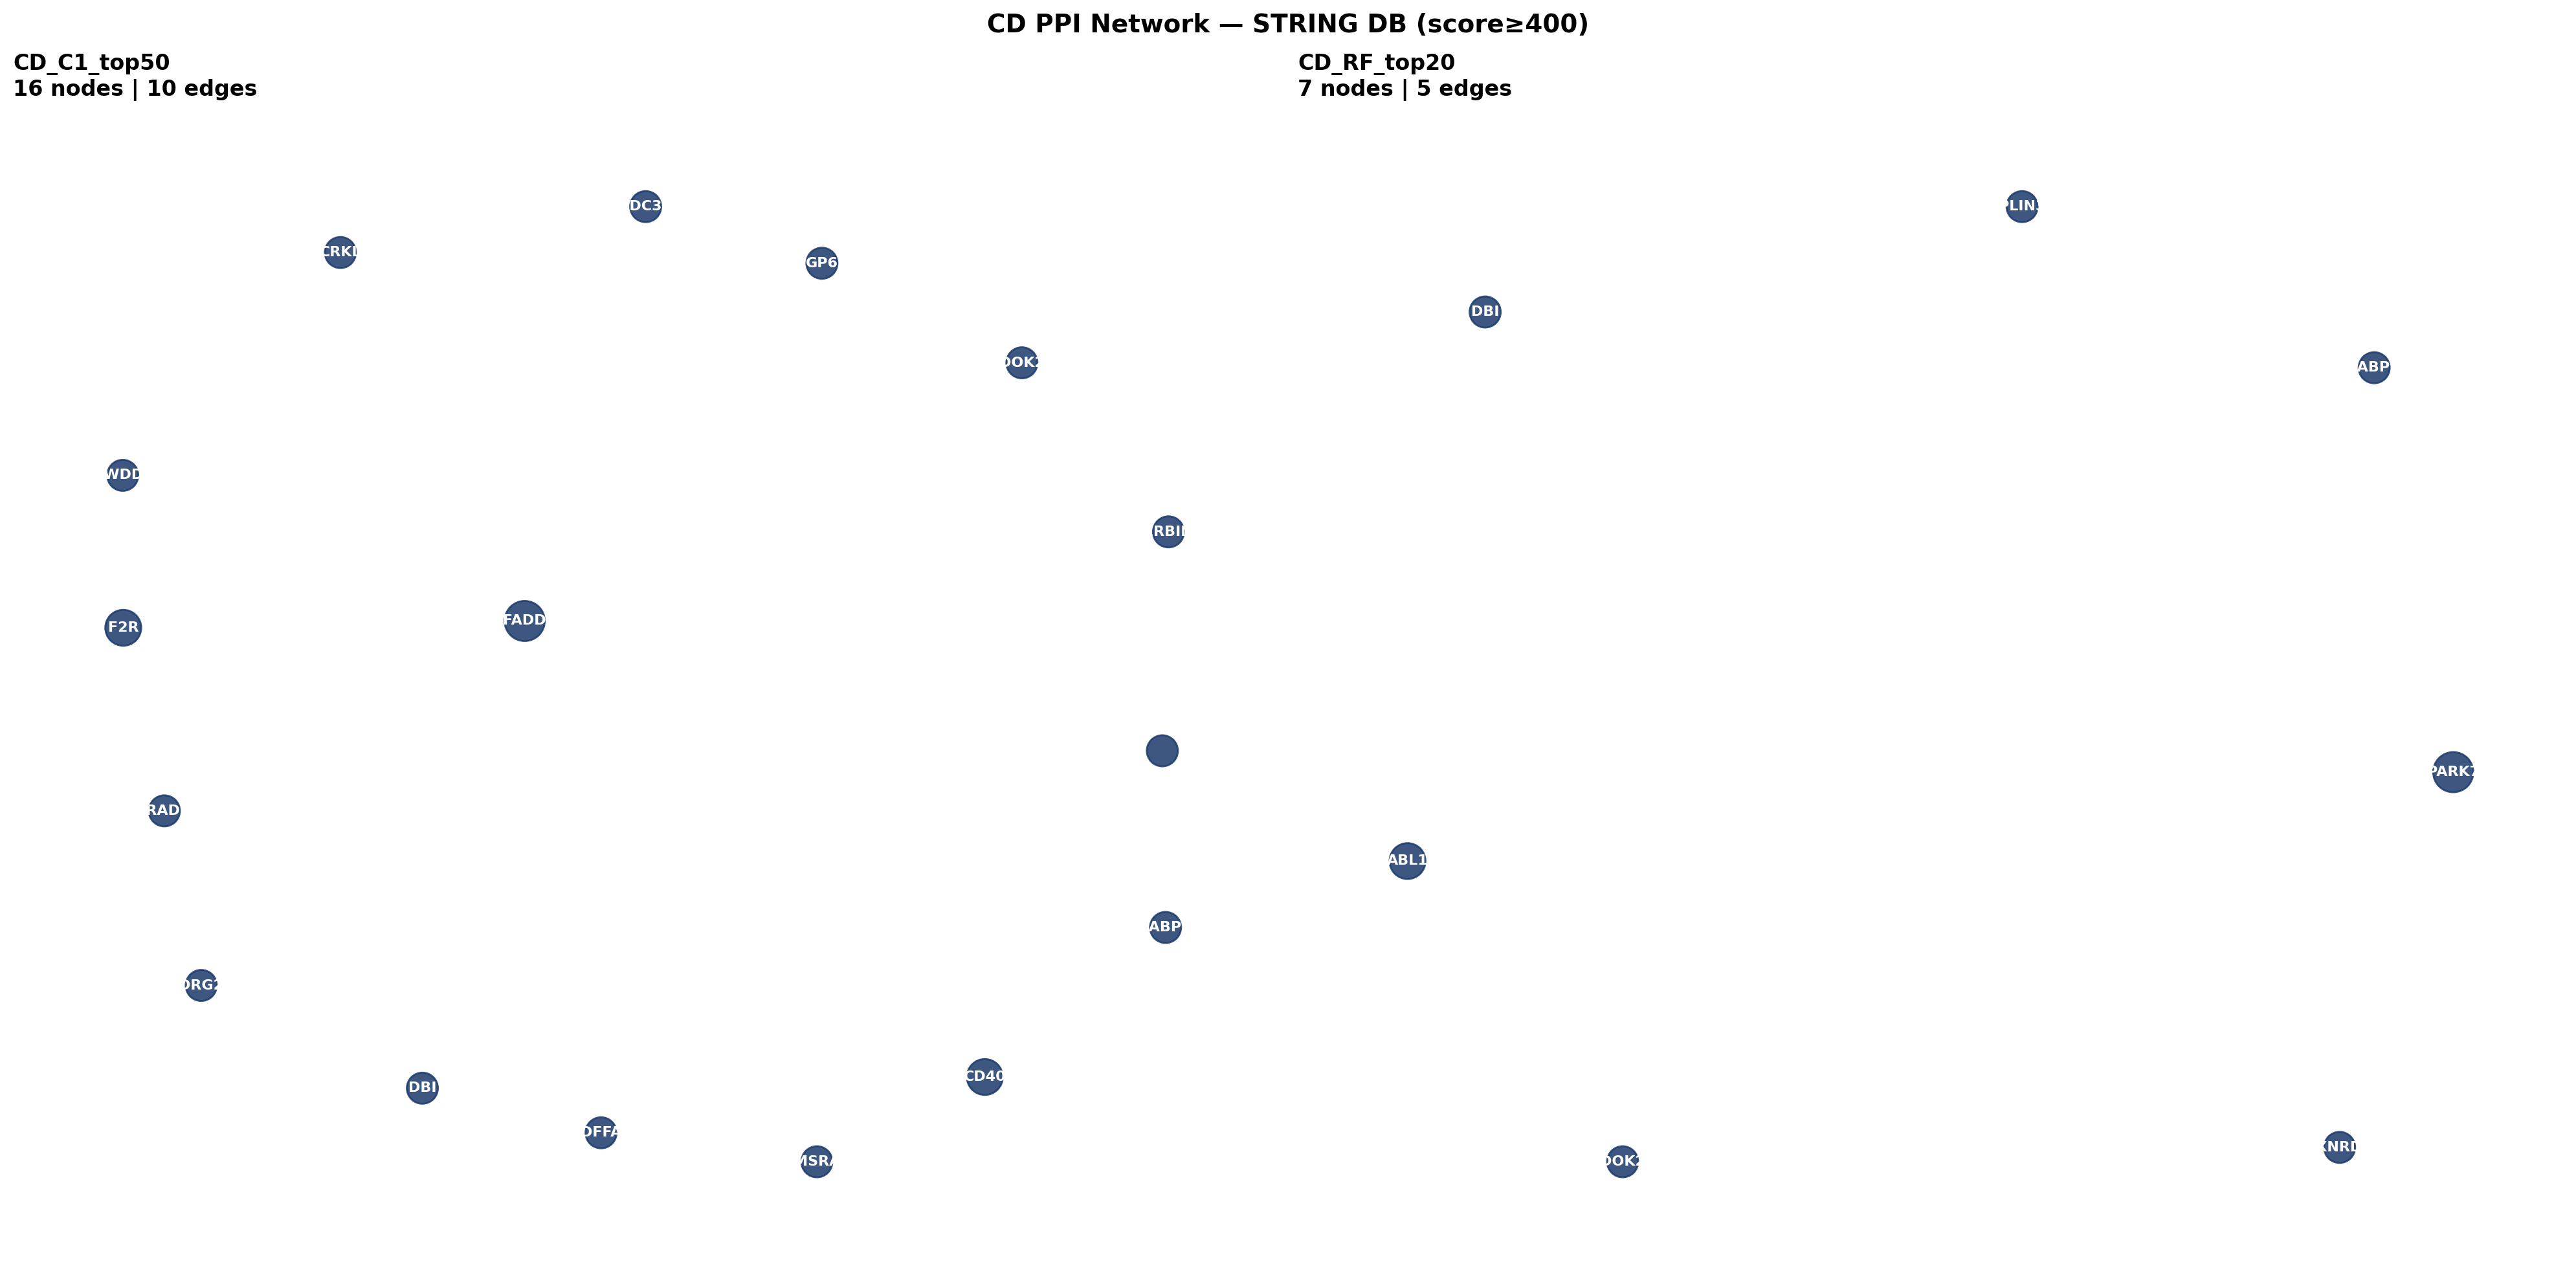

✓ Saved: ppi_uc.png

ppi_uc.png (234 KB):


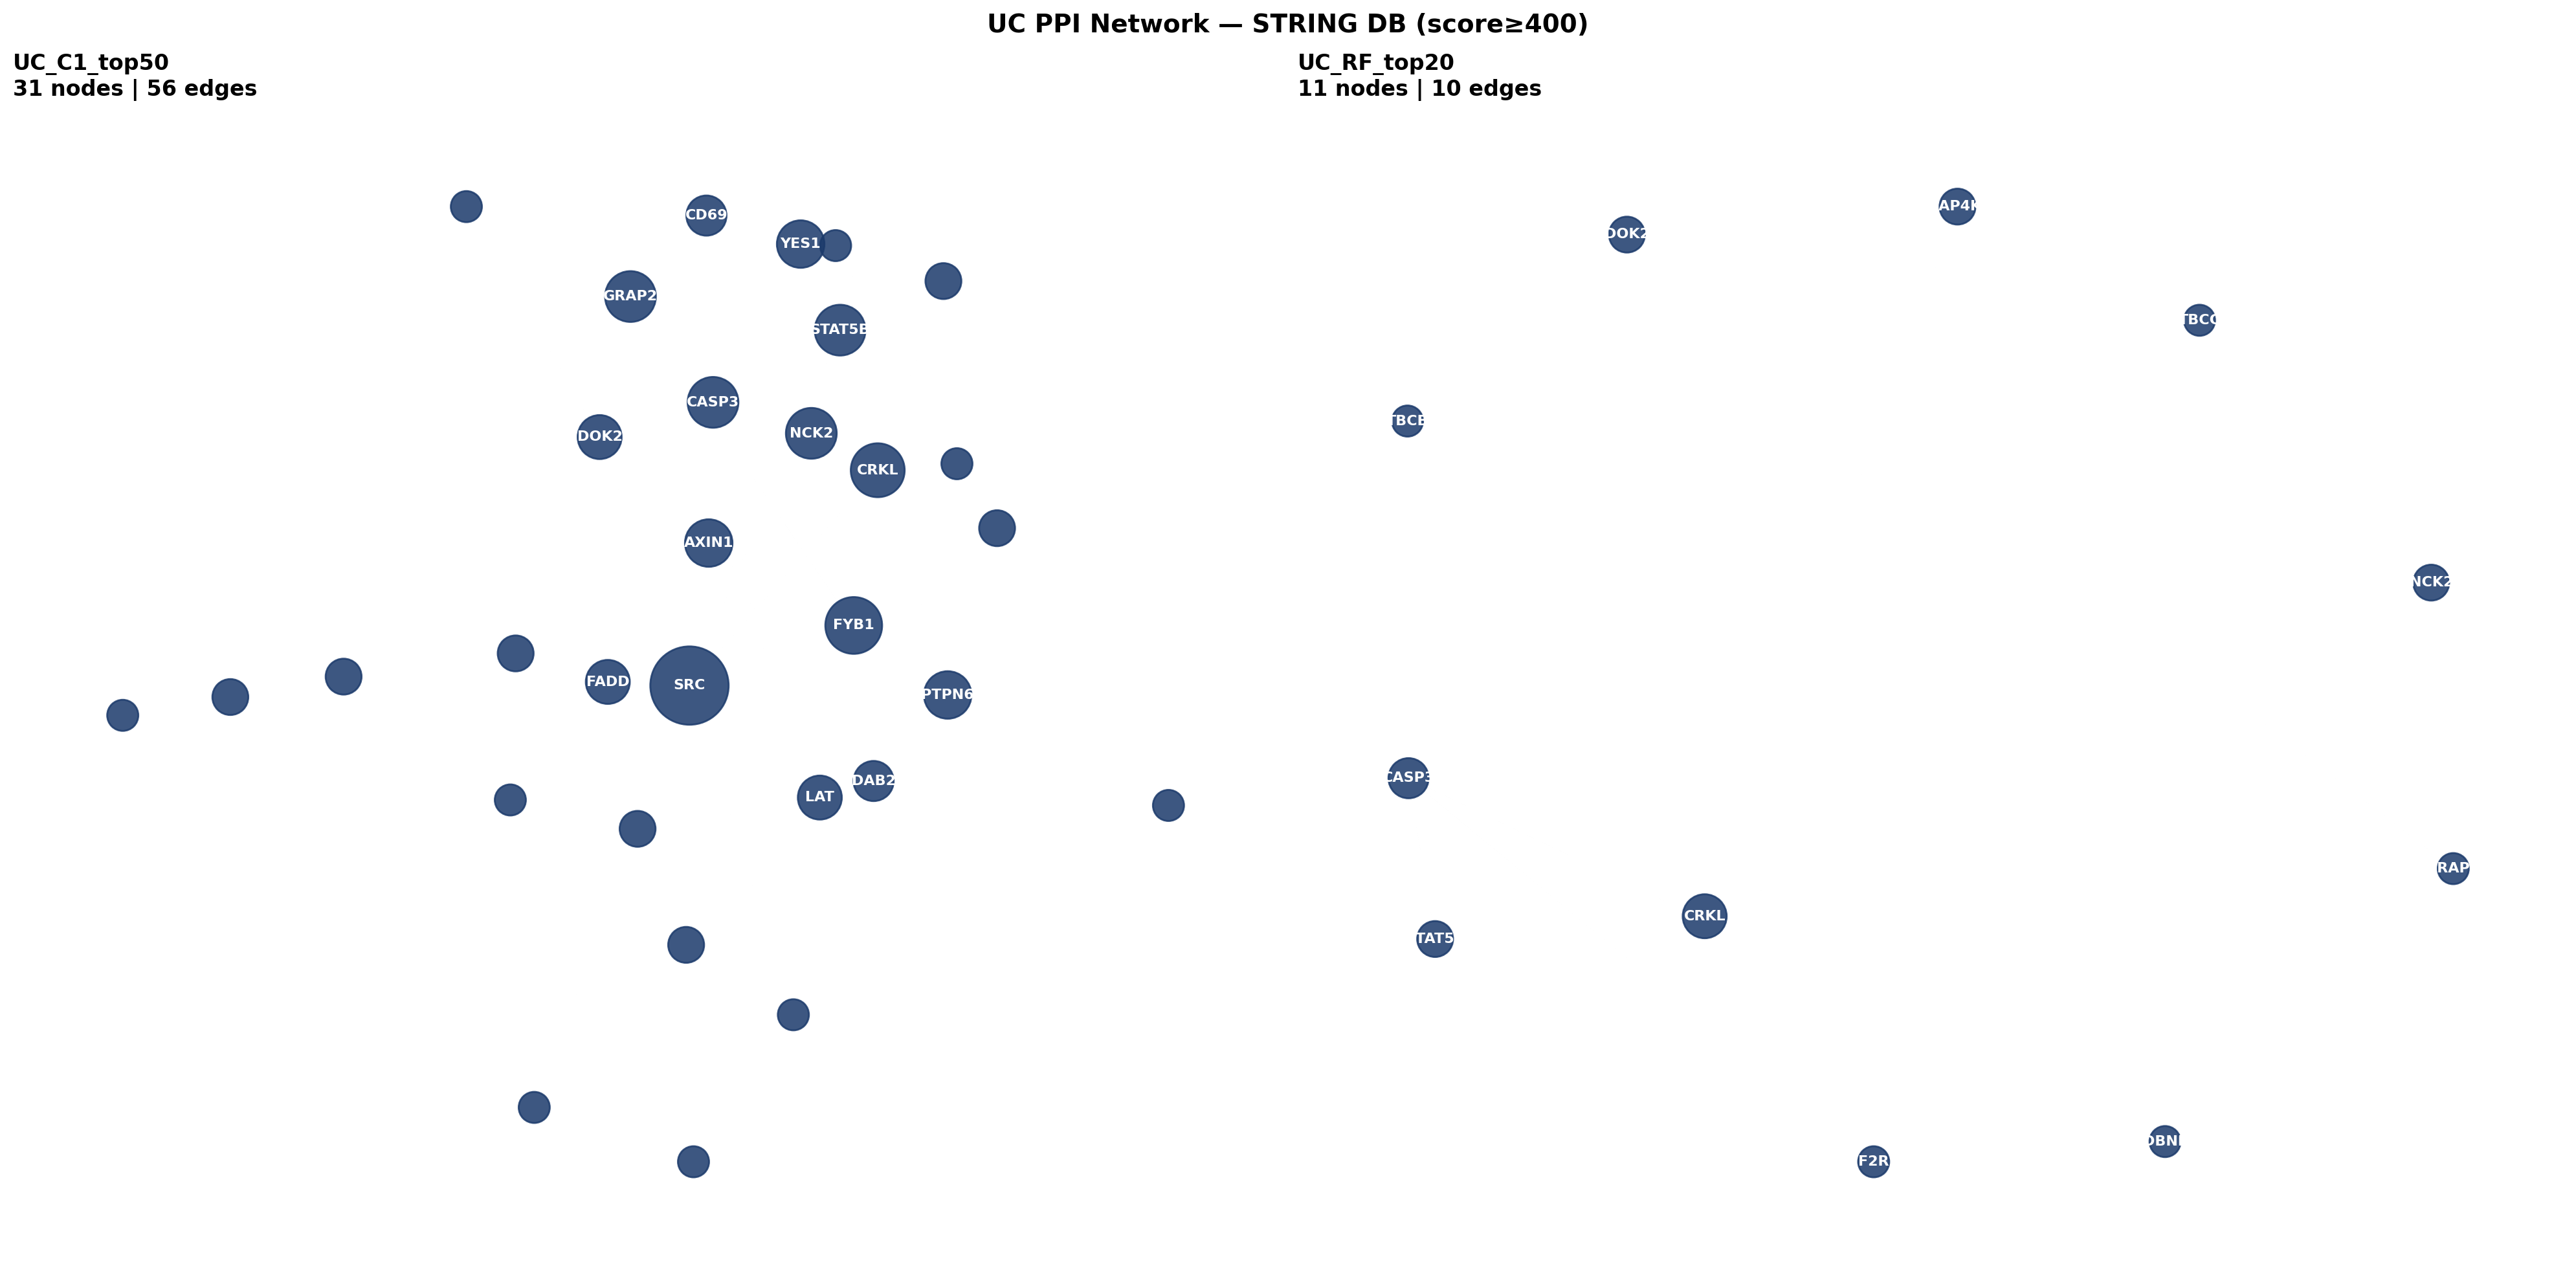


PPI COMPLETE
Next: Volcano plots + Heatmaps


In [3]:
# ── PPI visualisation ─────────────────────────────
def plot_ppi_network(edges_dict,
                      title, fname):
    try:
        import networkx as nx
        from matplotlib.colors import Normalize
        import matplotlib.cm as cm

        fig, axes = plt.subplots(
            1, len(edges_dict),
            figsize=(10*len(edges_dict), 10))
        fig.patch.set_facecolor('white')

        if len(edges_dict) == 1:
            axes = [axes]

        for ax, (label, edges) in zip(
                axes, edges_dict.items()):
            if edges is None or len(edges)==0:
                ax.text(0.5, 0.5,
                         'No network',
                         ha='center',
                         va='center',
                         transform=ax.transAxes)
                continue

            G = nx.Graph()
            for _, row in edges.iterrows():
                G.add_edge(
                    row['preferredName_A'],
                    row['preferredName_B'],
                    weight=row['score'])

            # Layout
            if len(G) < 30:
                pos = nx.spring_layout(
                    G, k=2, seed=42)
            else:
                pos = nx.kamada_kawai_layout(G)

            # Node size by degree
            degrees   = dict(G.degree())
            node_sizes = [
                200 + degrees[n]*100
                for n in G.nodes()]

            # Edge width by score
            weights   = [
                G[u][v]['weight']/1000
                for u,v in G.edges()]

            nx.draw_networkx_edges(
                G, pos, ax=ax,
                width=weights,
                alpha=0.4,
                edge_color='#AAAAAA')

            nx.draw_networkx_nodes(
                G, pos, ax=ax,
                node_size=node_sizes,
                node_color='#1B3A6B',
                alpha=0.85)

            # Label only hub nodes
            hub_nodes = {
                n:n for n,d in
                sorted(degrees.items(),
                        key=lambda x:x[1],
                        reverse=True)[:15]}
            nx.draw_networkx_labels(
                G, pos, hub_nodes, ax=ax,
                font_size=8,
                font_weight='bold',
                font_color='white')

            ax.set_facecolor('#F8F9FA')
            ax.axis('off')
            ax.set_title(
                f'{label}\n'
                f'{G.number_of_nodes()} nodes | '
                f'{G.number_of_edges()} edges',
                fontsize=12,
                fontweight='700',
                loc='left')

        plt.suptitle(title,
                      fontsize=14,
                      fontweight='900')
        plt.tight_layout()
        plt.savefig(fname, dpi=200,
                     bbox_inches='tight',
                     facecolor='white')
        plt.close()
        print(f'✓ Saved: {os.path.basename(fname)}')

    except ImportError:
        print('NetworkX not available '
              'for visualisation')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

for cohort in ['cd','uc']:
    edges_dict = {}
    for contrast in ['C1_top50','RF_top20']:
        path = (f'{TABLES_DIR}/'
                 f'ppi_{cohort.upper()}_'
                 f'{contrast}.csv')
        if os.path.exists(path):
            edges_dict[
                f'{cohort.upper()}_{contrast}'
            ] = pd.read_csv(path)

    if edges_dict:
        fname = (f'{FIGURES_DIR}/'
                  f'ppi_{cohort}.png')
        plot_ppi_network(
            edges_dict,
            f'{cohort.upper()} PPI Network — '
            f'STRING DB (score≥400)',
            fname)

        size = os.path.exists(fname) and \
               os.path.getsize(fname)//1024
        if size:
            print(f'\nppi_{cohort}.png '
                  f'({size} KB):')
            display(Image(filename=fname,
                          width=900))

print('\nPPI COMPLETE')
print('Next: Volcano plots + Heatmaps')

In [4]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib as mpl
from IPython.display import Image, display
import os

DATA_DIR    = '/rds/homes/j/jxt554/data'
TABLES_DIR  = '/rds/homes/j/jxt554/tables'
FIGURES_DIR = '/rds/homes/j/jxt554/figures'

prots = pd.read_csv(
    f'{DATA_DIR}/protein_cols_varfiltered.csv',
    header=None)[0].tolist()

PALETTE = {0:'#2E7D5B', 1:'#D97B2E'}
print('Making publication figures...')

Making publication figures...


In [5]:
# ── Figure 1: Volcano plots ───────────────────────
def make_volcano(cohort, label_up='C2',
                  label_dn='C1'):
    df = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_limma_M3.csv')
    df['log_q'] = -np.log10(
        df['adj.P.Val'].clip(lower=1e-300))

    FDR  = 0.05
    sig_up = (df['adj.P.Val']<FDR) & \
             (df['logFC']>0)
    sig_dn = (df['adj.P.Val']<FDR) & \
             (df['logFC']<0)
    ns     = ~(sig_up|sig_dn)

    fig, ax = plt.subplots(figsize=(10,8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.12, linestyle='--',
            color='#ccc', zorder=0)

    ax.scatter(df.loc[ns,'logFC'],
                df.loc[ns,'log_q'],
                c='#CCCCCC', s=8, alpha=0.4,
                linewidths=0, zorder=1,
                rasterized=True)
    ax.scatter(df.loc[sig_dn,'logFC'],
                df.loc[sig_dn,'log_q'],
                c=PALETTE[0], s=14, alpha=0.7,
                linewidths=0, zorder=2,
                rasterized=True)
    ax.scatter(df.loc[sig_up,'logFC'],
                df.loc[sig_up,'log_q'],
                c=PALETTE[1], s=14, alpha=0.7,
                linewidths=0, zorder=2,
                rasterized=True)

    # Annotate top proteins
    for mask, col, n in [
        (sig_dn, PALETTE[0], 8),
        (sig_up, PALETTE[1], 5)]:
        top = df[mask].nsmallest(
            n,'adj.P.Val')
        for _, row in top.iterrows():
            ax.annotate(
                row['protein'],
                (row['logFC'], row['log_q']),
                fontsize=8, style='italic',
                fontweight='700', color=col,
                xytext=(8,2),
                textcoords='offset points')

    ax.axhline(-np.log10(FDR),
                color='#555',
                linestyle='--',
                linewidth=1.0, alpha=0.7)
    ax.axvline(0, color='#aaa',
                linewidth=0.8, alpha=0.5)
    ax.text(0.98, 0.98,
             f'↑ {label_dn}: '
             f'{sig_dn.sum()} proteins\n'
             f'↑ {label_up}: '
             f'{sig_up.sum()} proteins\n'
             f'M3 fully adjusted\n'
             f'FDR q < {FDR}',
             transform=ax.transAxes,
             ha='right', va='top',
             fontsize=10,
             fontfamily='monospace',
             bbox=dict(
                 boxstyle='round,pad=0.4',
                 facecolor='white',
                 edgecolor='#ccc',
                 alpha=0.95))
    ax.set_xlabel('log₂ FC (C2 vs C1)',
                   fontsize=13)
    ax.set_ylabel('-log₁₀(FDR)',
                   fontsize=13)
    ax.set_title(
        f'{cohort.upper()} — '
        f'Differential protein abundance\n'
        f'limma M3 (fully adjusted) | '
        f'n={len(df)} proteins tested',
        fontsize=12, fontweight='700',
        loc='left', pad=10)
    ax.legend(handles=[
        Line2D([0],[0], marker='o',
                color='w',
                markerfacecolor=PALETTE[0],
                markersize=10,
                label=f'Higher in C1 '
                      f'(n={sig_dn.sum()})'),
        Line2D([0],[0], marker='o',
                color='w',
                markerfacecolor=PALETTE[1],
                markersize=10,
                label=f'Higher in C2 '
                      f'(n={sig_up.sum()})'),
        Line2D([0],[0], marker='o',
                color='w',
                markerfacecolor='#CCCCCC',
                markersize=10,
                label='ns')],
        fontsize=10, loc='upper left')

    plt.tight_layout()
    fname = (f'{FIGURES_DIR}/'
              f'volcano_{cohort}.png')
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: volcano_{cohort}.png')

make_volcano('cd')
make_volcano('uc')

✓ Saved: volcano_cd.png
✓ Saved: volcano_uc.png


In [7]:
# ── Figure 2: Heatmap top DE proteins ─────────────
def make_heatmap(cohort):
    df     = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_limma_M3.csv')
    meta   = pd.read_csv(
        f'{DATA_DIR}/meta_{cohort}_final.csv')
    X      = np.load(
        f'{DATA_DIR}/X_{cohort}_int.npy')
    labels = meta['cluster'].values
    N      = len(labels)

    n_prots = min(len(prots), X.shape[1])
    X       = X[:,:n_prots]
    df_idx  = df.set_index('protein')

    # Top 25 C1 + top 5 C2 proteins
    top_c1 = df[df['logFC']<0].nsmallest(
        25,'adj.P.Val')['protein'].tolist()
    top_c2 = df[df['logFC']>0].nsmallest(
        5,'adj.P.Val')['protein'].tolist()
    top_all = top_c1 + top_c2
    top_all = [p for p in top_all
                if p in prots[:n_prots]]

    prot_idx = [prots.index(p)
                 for p in top_all]
    X_sub    = X[:,prot_idx]
    # Z-score
    X_z = (X_sub - X_sub.mean(axis=0)) / \
          (X_sub.std(axis=0) + 1e-8)

    # Sort by cluster
    sort_idx = np.argsort(labels)
    X_sorted = X_z[sort_idx].T
    l_sorted = labels[sort_idx]

    fig, axes = plt.subplots(
        1, 2, figsize=(18,12),
        gridspec_kw={'width_ratios':[0.04,1]})
    fig.patch.set_facecolor('white')

    # Colour bar
    ax_bar = axes[0]
    ax_bar.set_facecolor('white')
    for s in ax_bar.spines.values():
        s.set_visible(False)
    for yi, c in enumerate(l_sorted):
        ax_bar.barh(yi, 1,
                     color=PALETTE[c],
                     linewidth=0)
    ax_bar.set_xlim(0,1)
    ax_bar.set_ylim(-0.5, N-0.5)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    boundary = (l_sorted==0).sum() - 0.5
    ax_bar.axhline(boundary,
                    color='white',
                    linewidth=2)

    # Heatmap
    ax = axes[1]
    im = ax.imshow(
        X_sorted, cmap='RdBu_r',
        vmin=-3, vmax=3,
        aspect='auto')
    ax.axvline(boundary,
                color='white', linewidth=2.5)
    ax.set_yticks(range(len(top_all)))
    ax.set_yticklabels(top_all, fontsize=9,
                        style='italic')
    ax.set_xticks([])
    ax.set_xlabel(
        f'Patients (n={N}) sorted by cluster',
        fontsize=12)
    plt.colorbar(im, ax=ax,
                  label='Z-score',
                  shrink=0.5)

    # Cluster labels
    for c in range(2):
        mask = l_sorted==c
        mid  = np.where(mask)[0].mean()
        ax.text(mid, -1.5,
                 f'C{c+1}\n'
                 f'(n={mask.sum()})',
                 ha='center', va='bottom',
                 fontsize=11,
                 fontweight='700',
                 color=PALETTE[c])

    # Separator
    ax.axhline(len(top_c1)-0.5,
                color='black',
                linewidth=1.5,
                linestyle='--', alpha=0.5)
    ax.text(N+2, len(top_c1)-3,
             'C1\nmarkers', fontsize=9,
             color=PALETTE[0],
             fontweight='700')
    ax.text(N+2, len(top_c1)+1,
             'C2\nmarkers', fontsize=9,
             color=PALETTE[1],
             fontweight='700')

    ax.set_title(
        f'{cohort.upper()} — '
        'Top DE proteins\n'
        f'Top 25 C1 + top {len(top_c2)} C2 '
        f'| limma M3 | FDR<0.05',
        fontsize=12, fontweight='700',
        loc='left', pad=10)

    plt.suptitle(
        f'{cohort.upper()} proteomic subtypes '
        '— differential abundance heatmap',
        fontsize=13, fontweight='900',
        y=1.01)
    plt.tight_layout()
    fname = f'{FIGURES_DIR}/heatmap_{cohort}.png'
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: heatmap_{cohort}.png')

make_heatmap('cd')
make_heatmap('uc')

✓ Saved: heatmap_cd.png
✓ Saved: heatmap_uc.png


In [9]:
# ── Figure 3: ORA Hallmark bar charts ─────────────
def make_hallmark_plot(cohort):
    path = (f'{TABLES_DIR}/'
             f'ora_{cohort}_C1_up_Hallmark.csv')
    if not os.path.exists(path):
        print(f'ORA not found for {cohort}')
        return

    df = pd.read_csv(path, encoding='utf-8')
    df['Term_clean'] = (
        df['Term']
        .str.replace(r'\s+R-HSA-\d+','',
                      regex=True)
        .str.replace(r'\s+\(GO:\d+\)','',
                      regex=True)
        .str.strip())
    df['log_fdr'] = -np.log10(
        df['Adjusted P-value'].clip(
            lower=1e-300))
    df = df[df['Adjusted P-value']<0.05
            ].sort_values(
        'log_fdr', ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(12,9))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.2,
            linestyle='--', color='#ccc',
            zorder=0)
    ax.tick_params(length=0)

    norm   = plt.Normalize(
        df['log_fdr'].min(),
        df['log_fdr'].max())
    cmap   = mpl.colormaps.get_cmap('YlOrRd')
    colors = [cmap(0.4+0.5*norm(v))
               for v in df['log_fdr']]

    bars = ax.barh(
        range(len(df)),
        df['log_fdr'],
        color=colors,
        height=0.65,
        edgecolor='white',
        linewidth=0.8,
        zorder=3)

    for bar, (_, row) in zip(
            bars, df.iterrows()):
        ax.text(
            bar.get_width()+0.1,
            bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}',
            va='center', fontsize=9.5,
            color='#444', fontweight='600')

    ax.axvline(-np.log10(0.05),
                color='#E24B4A',
                linewidth=1.5,
                linestyle=':', alpha=0.8,
                label='FDR=0.05')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(
        [t[:55] for t in
         df['Term_clean']], fontsize=10)
    ax.set_xlabel('-log₁₀(FDR q-value)',
                   fontsize=12)
    ax.legend(fontsize=10)
    ax.set_title(
        f'{cohort.upper()} C1 — '
        f'Hallmark pathway enrichment\n'
        f'ORA | {len(df)} significant | '
        f'C1 hyperinflammatory proteins',
        fontsize=12, fontweight='700',
        loc='left', pad=10)

    plt.tight_layout()
    fname = (f'{FIGURES_DIR}/'
              f'hallmark_{cohort}.png')
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: hallmark_{cohort}.png')

make_hallmark_plot('cd')
make_hallmark_plot('uc')

✓ Saved: hallmark_cd.png
✓ Saved: hallmark_uc.png


✓ Saved: rf_triangulation_cd.png
✓ Saved: rf_triangulation_uc.png

Displaying all figures...

volcano_cd.png (199 KB):


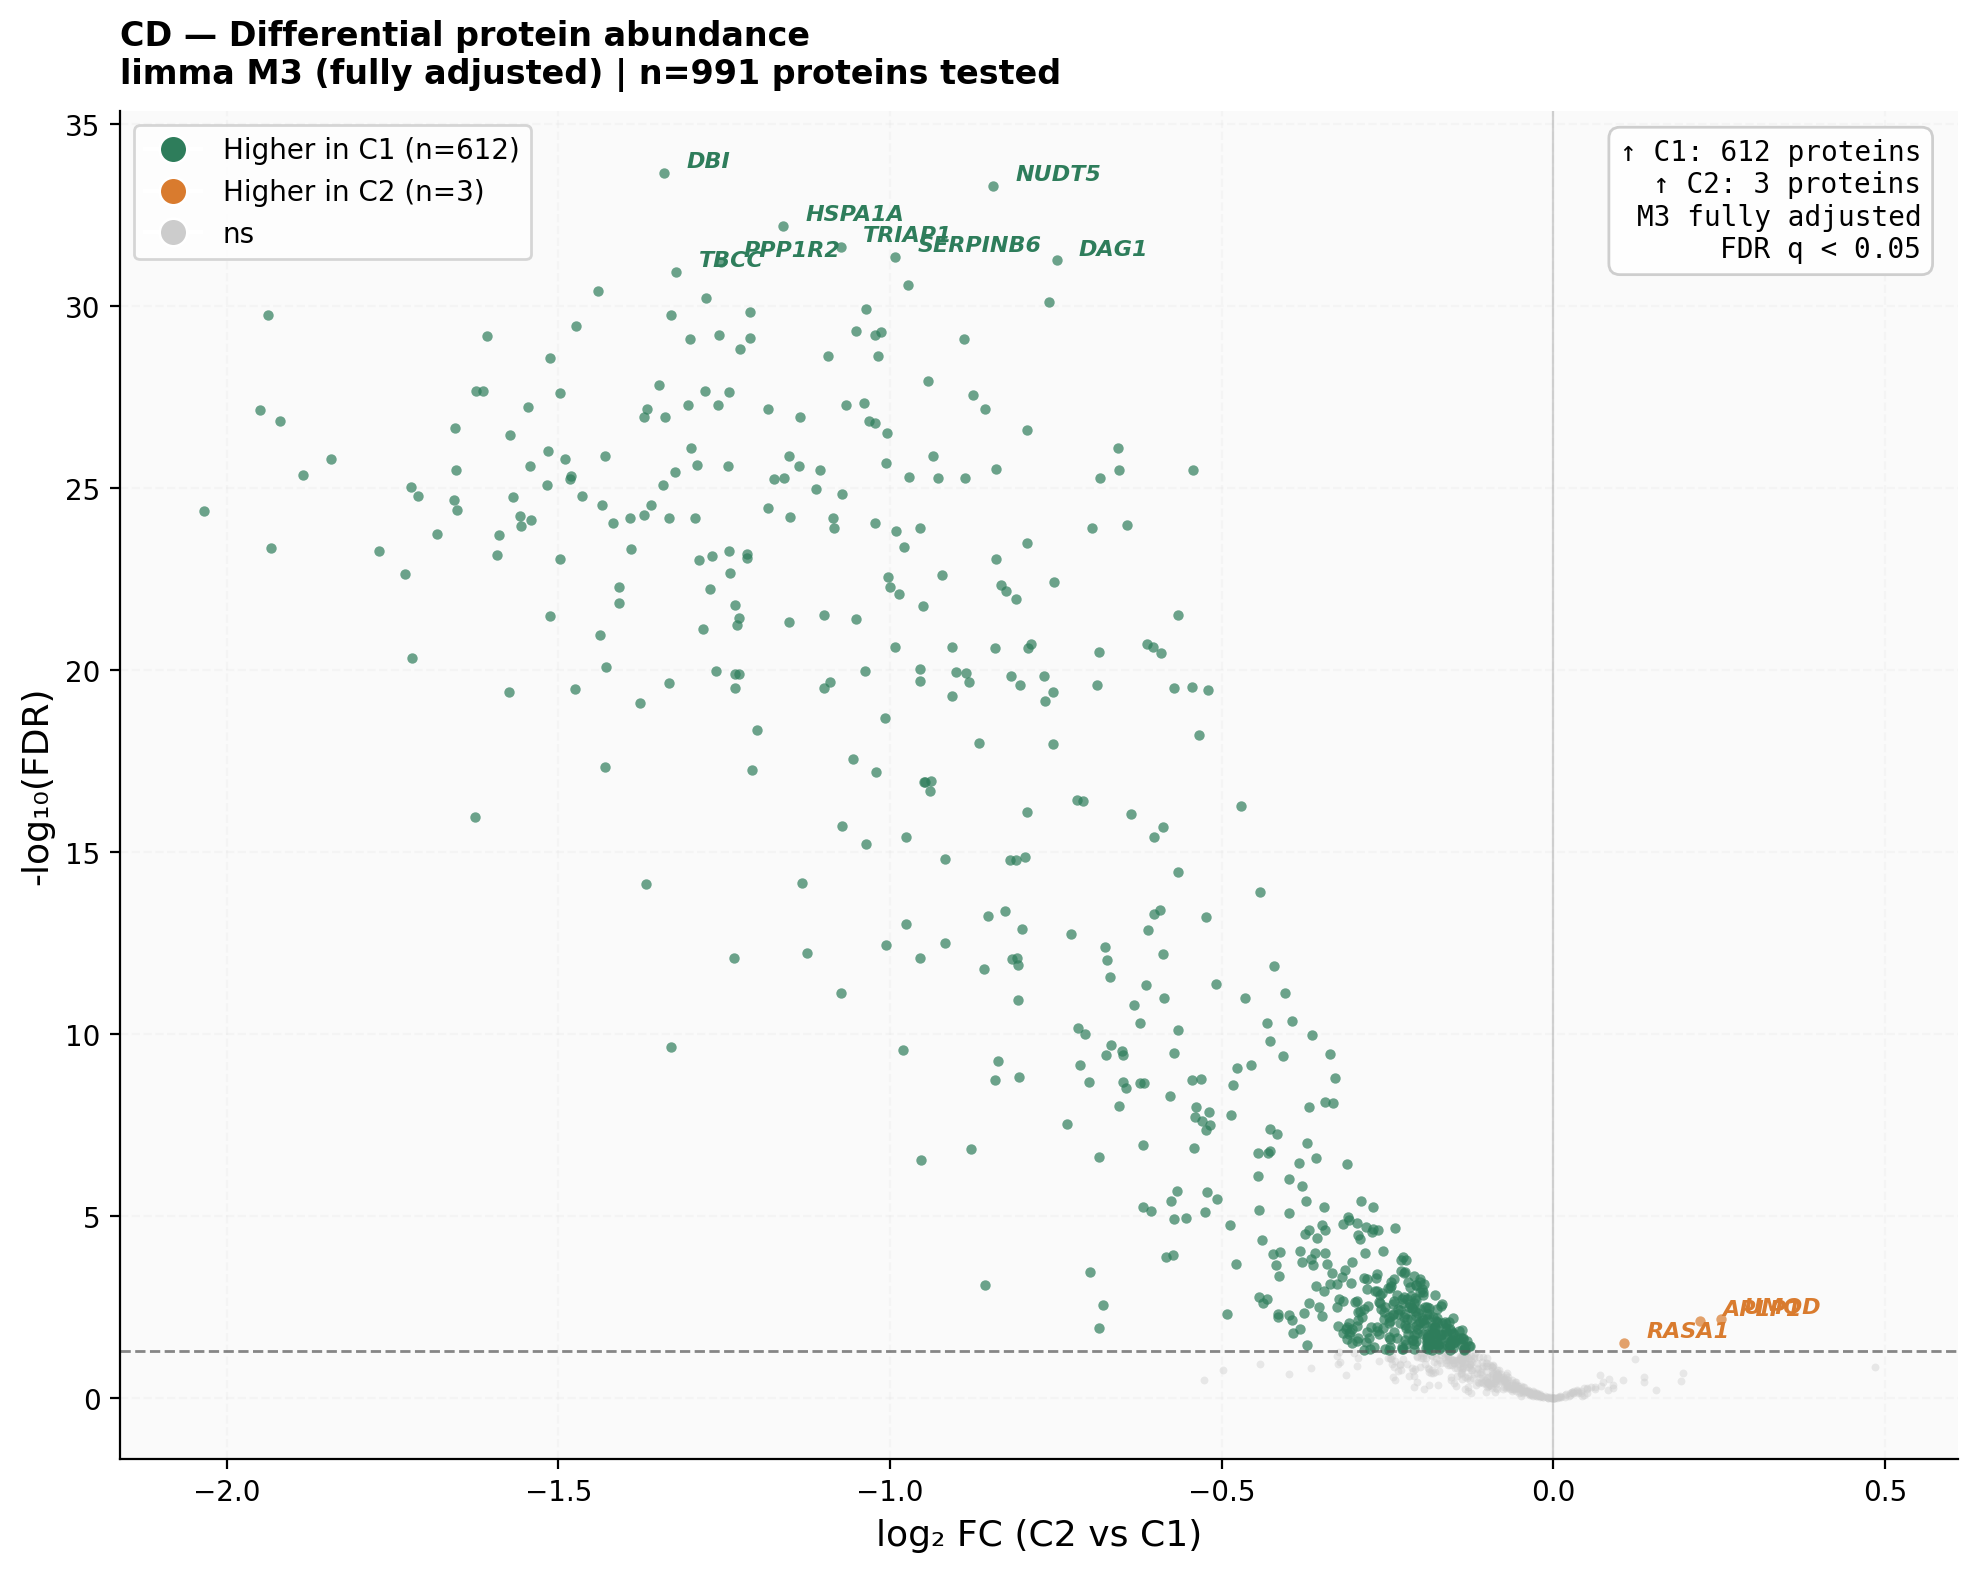


volcano_uc.png (196 KB):


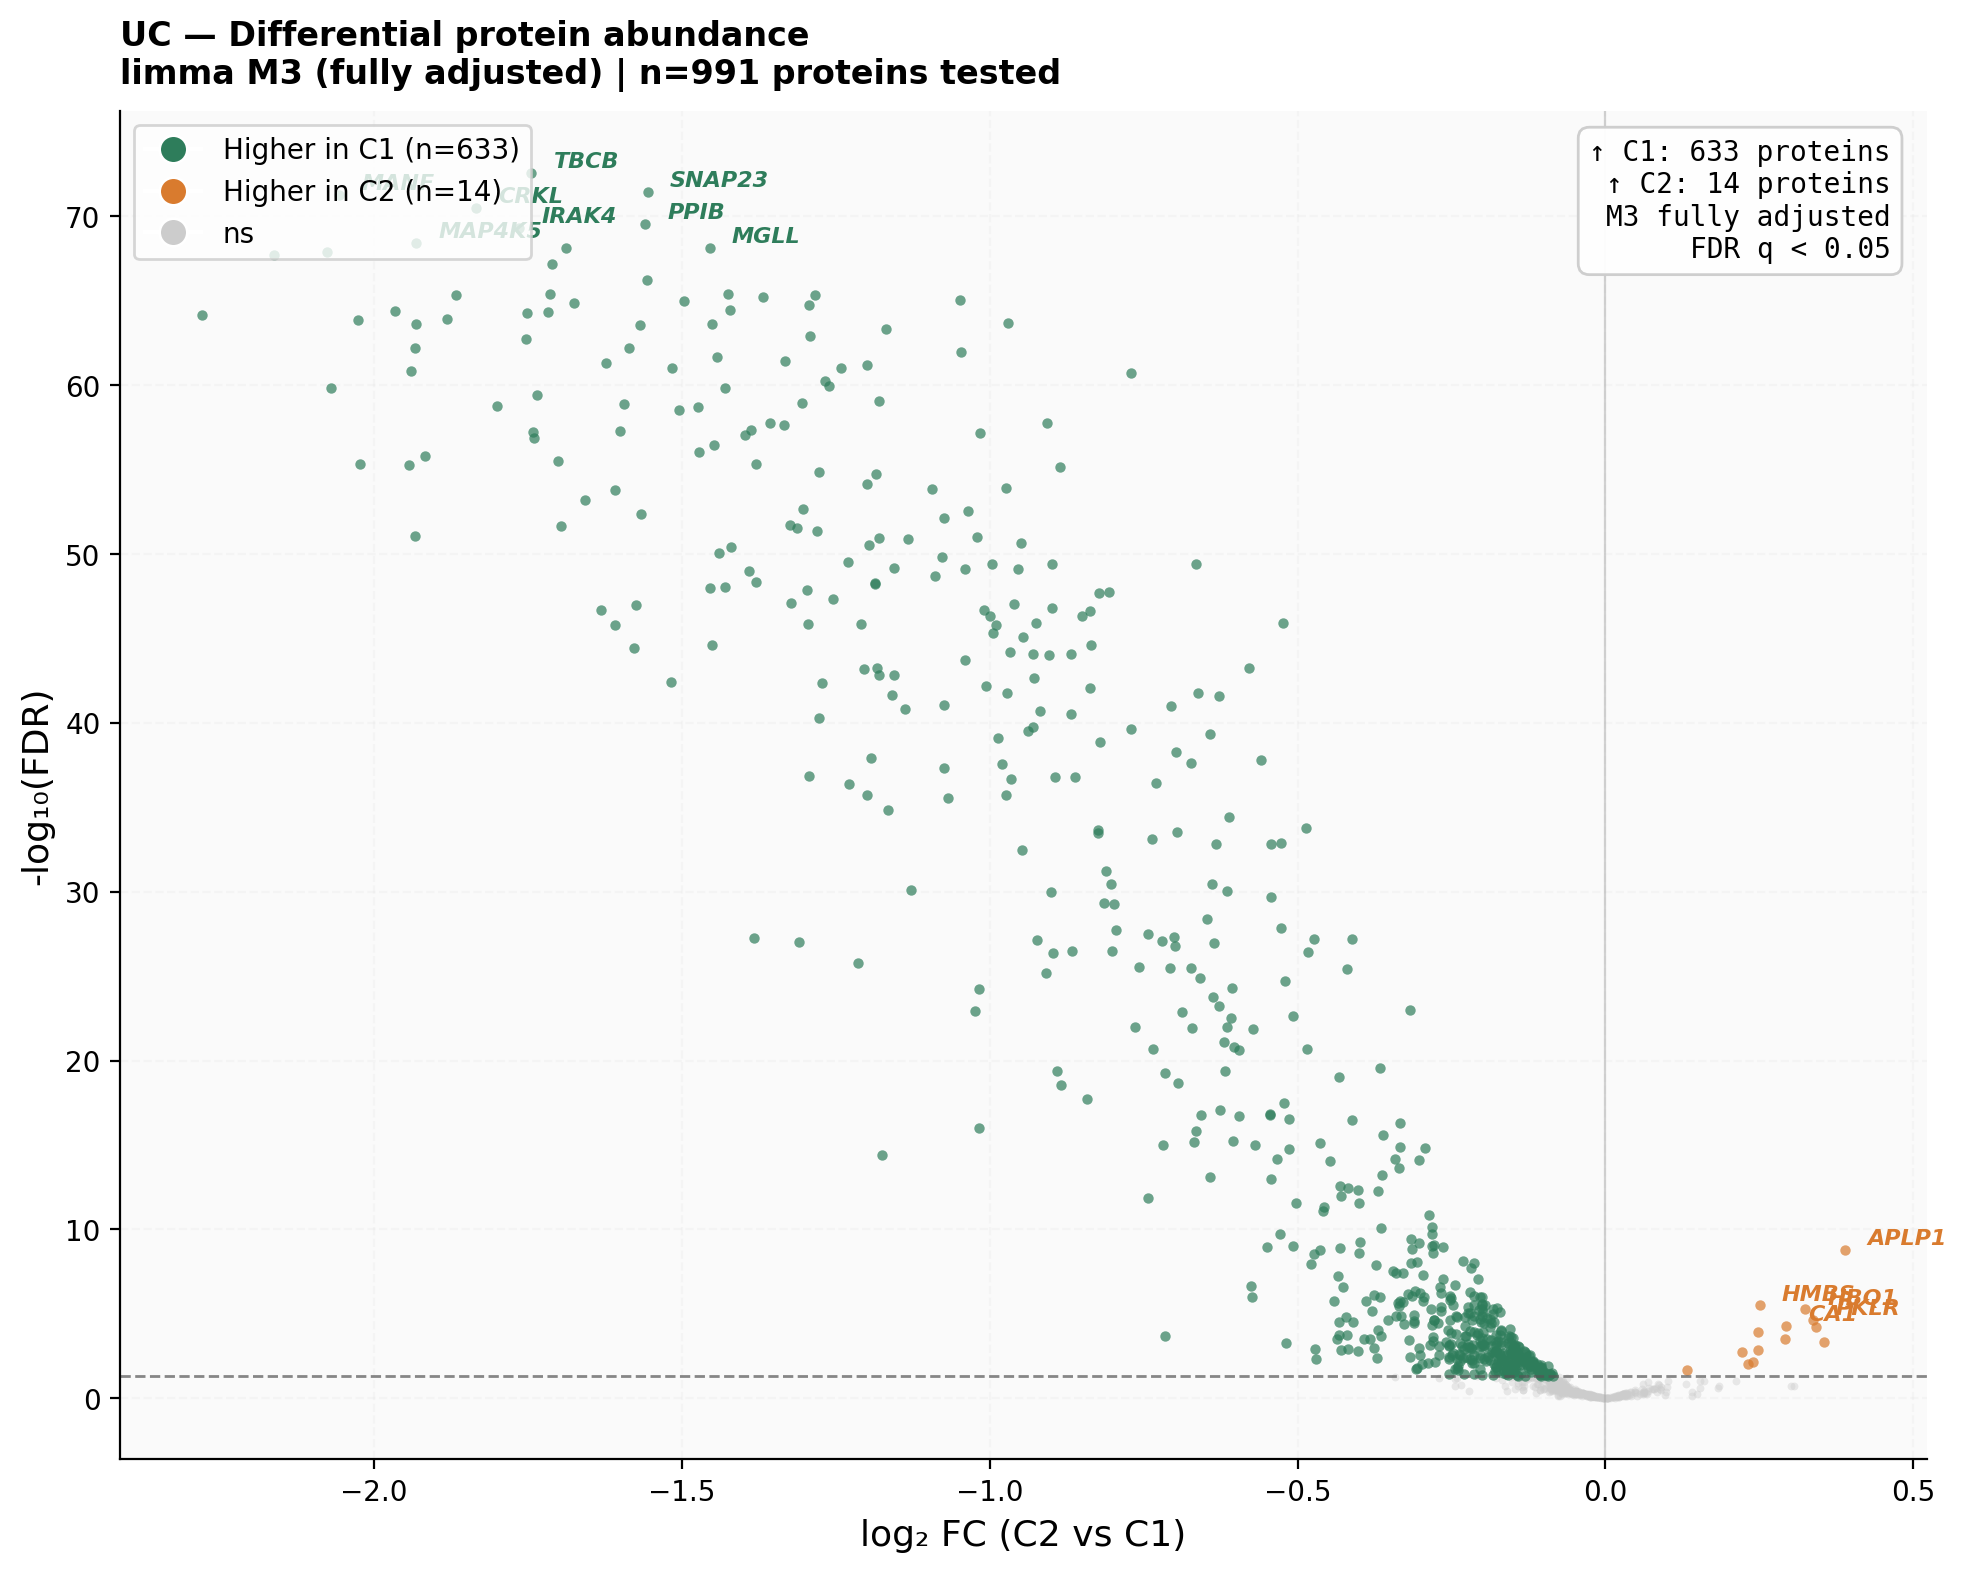


heatmap_cd.png (233 KB):


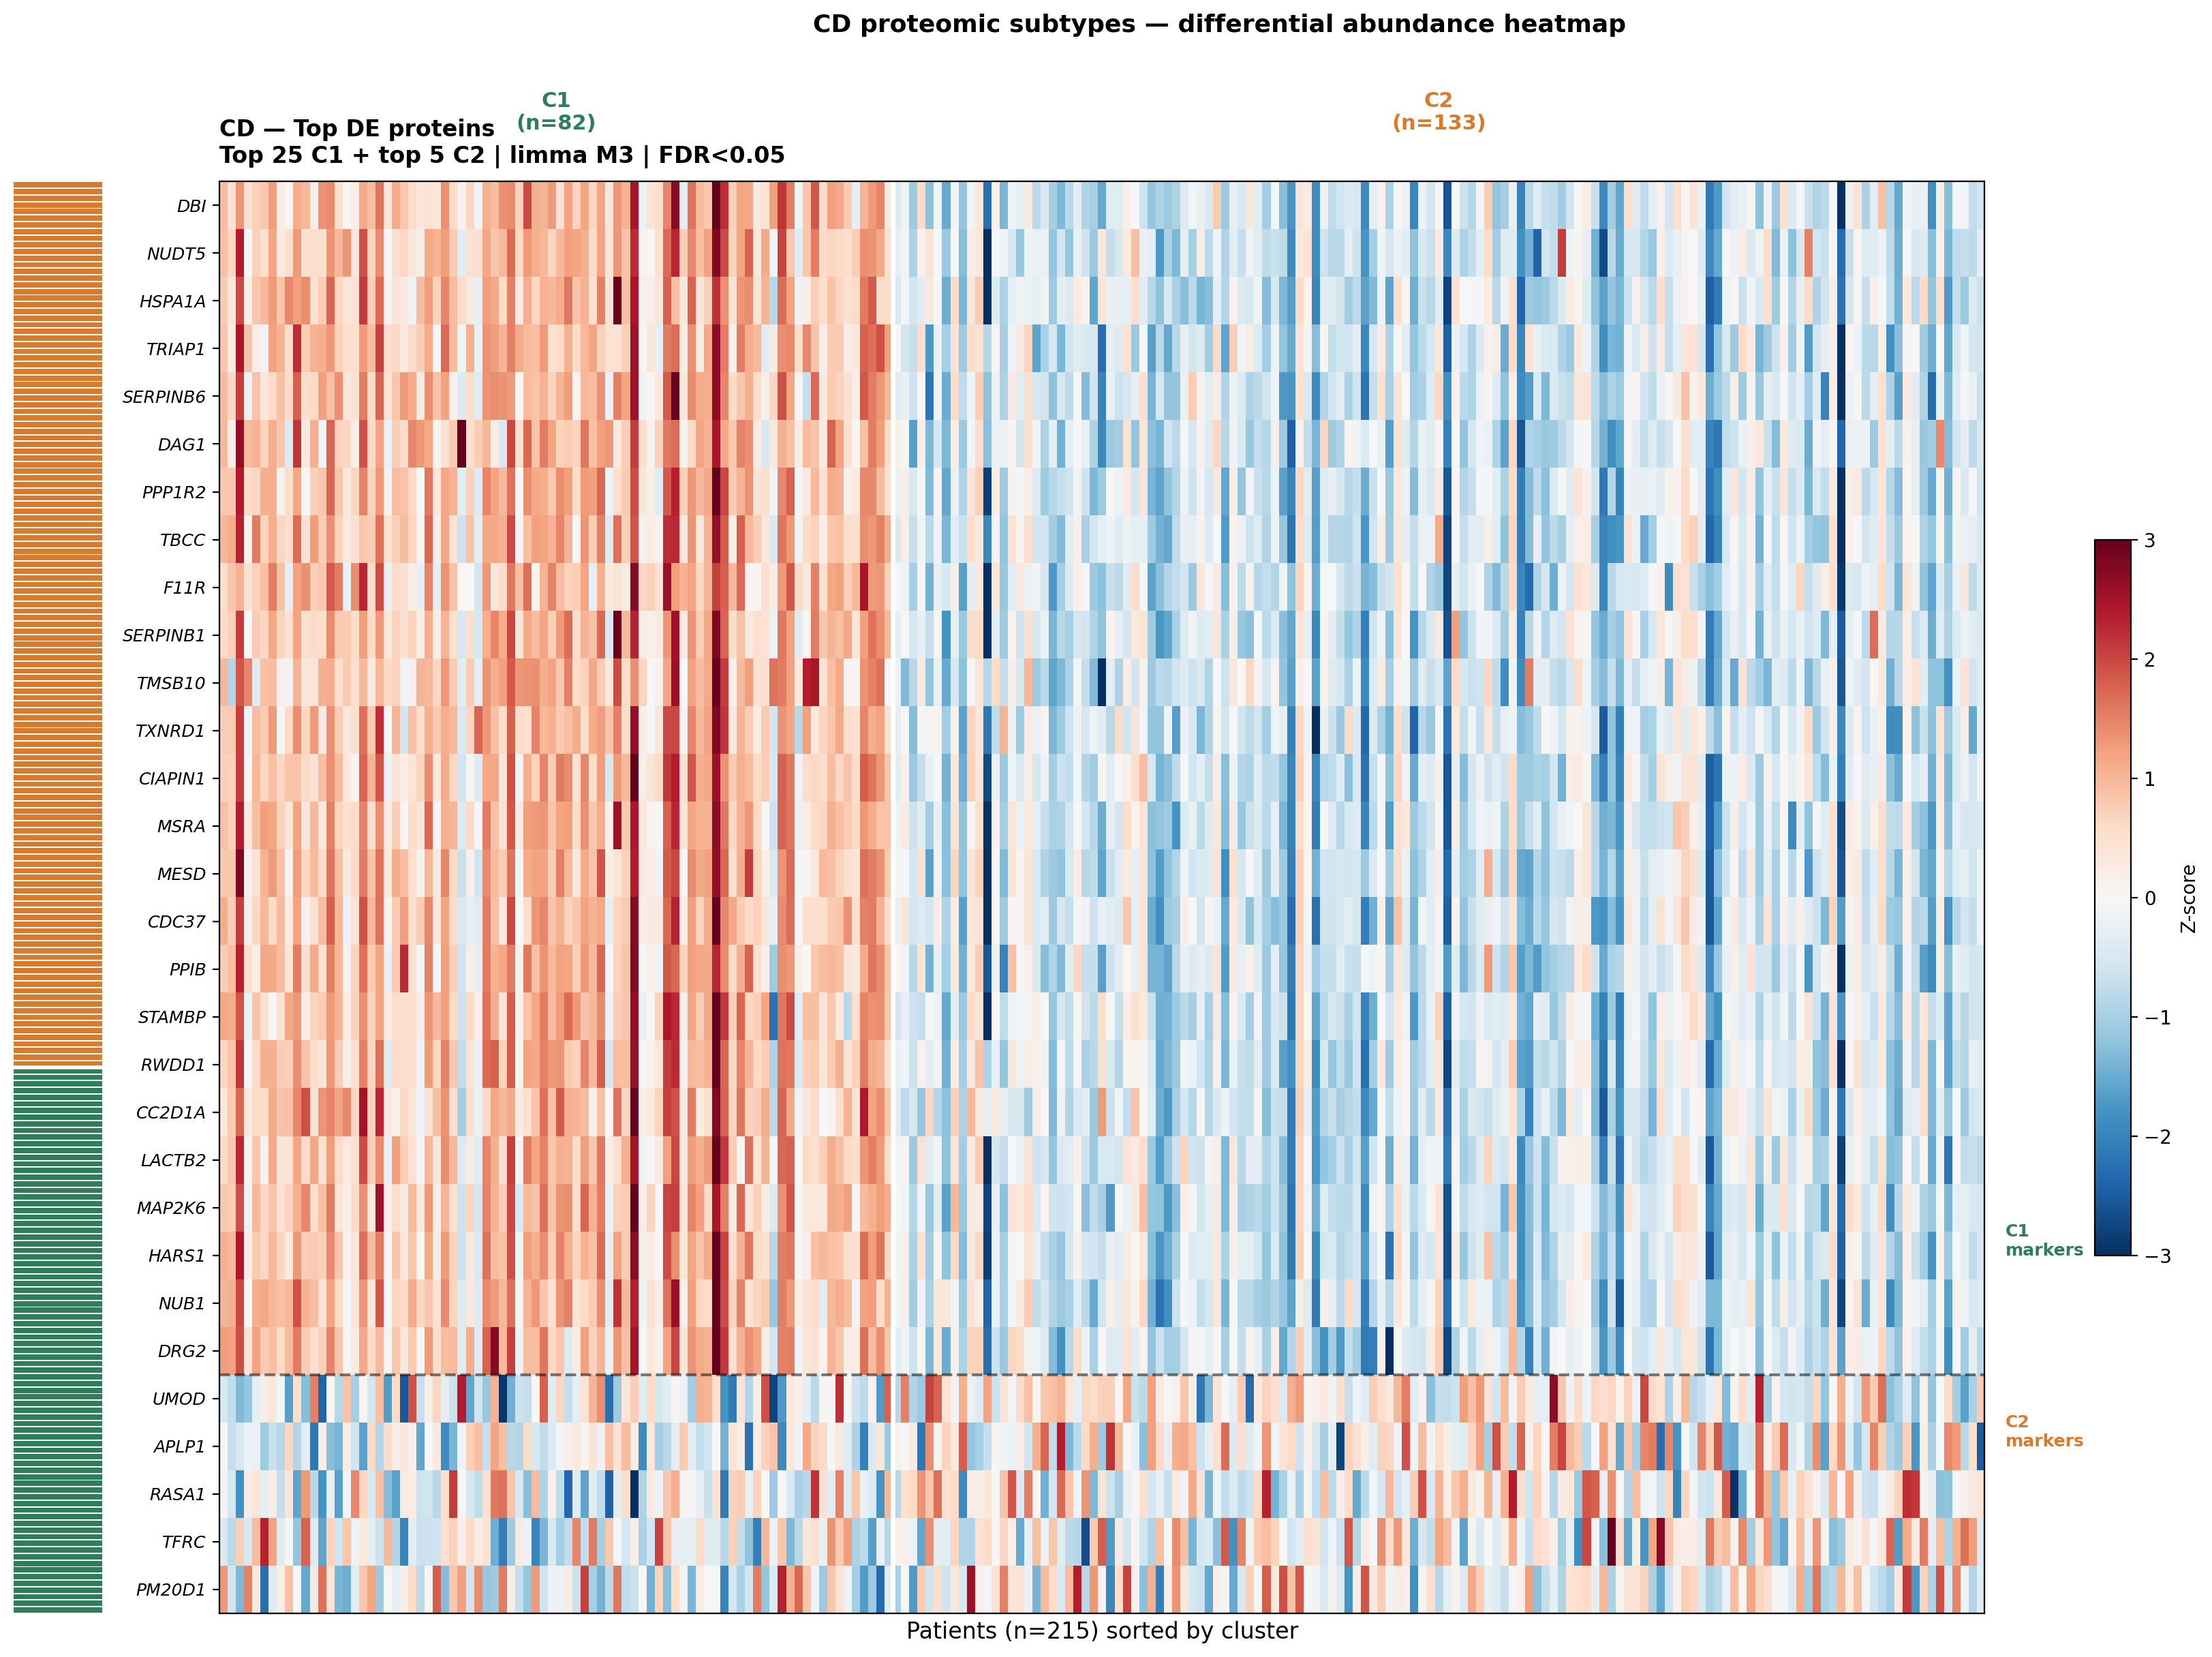


heatmap_uc.png (264 KB):


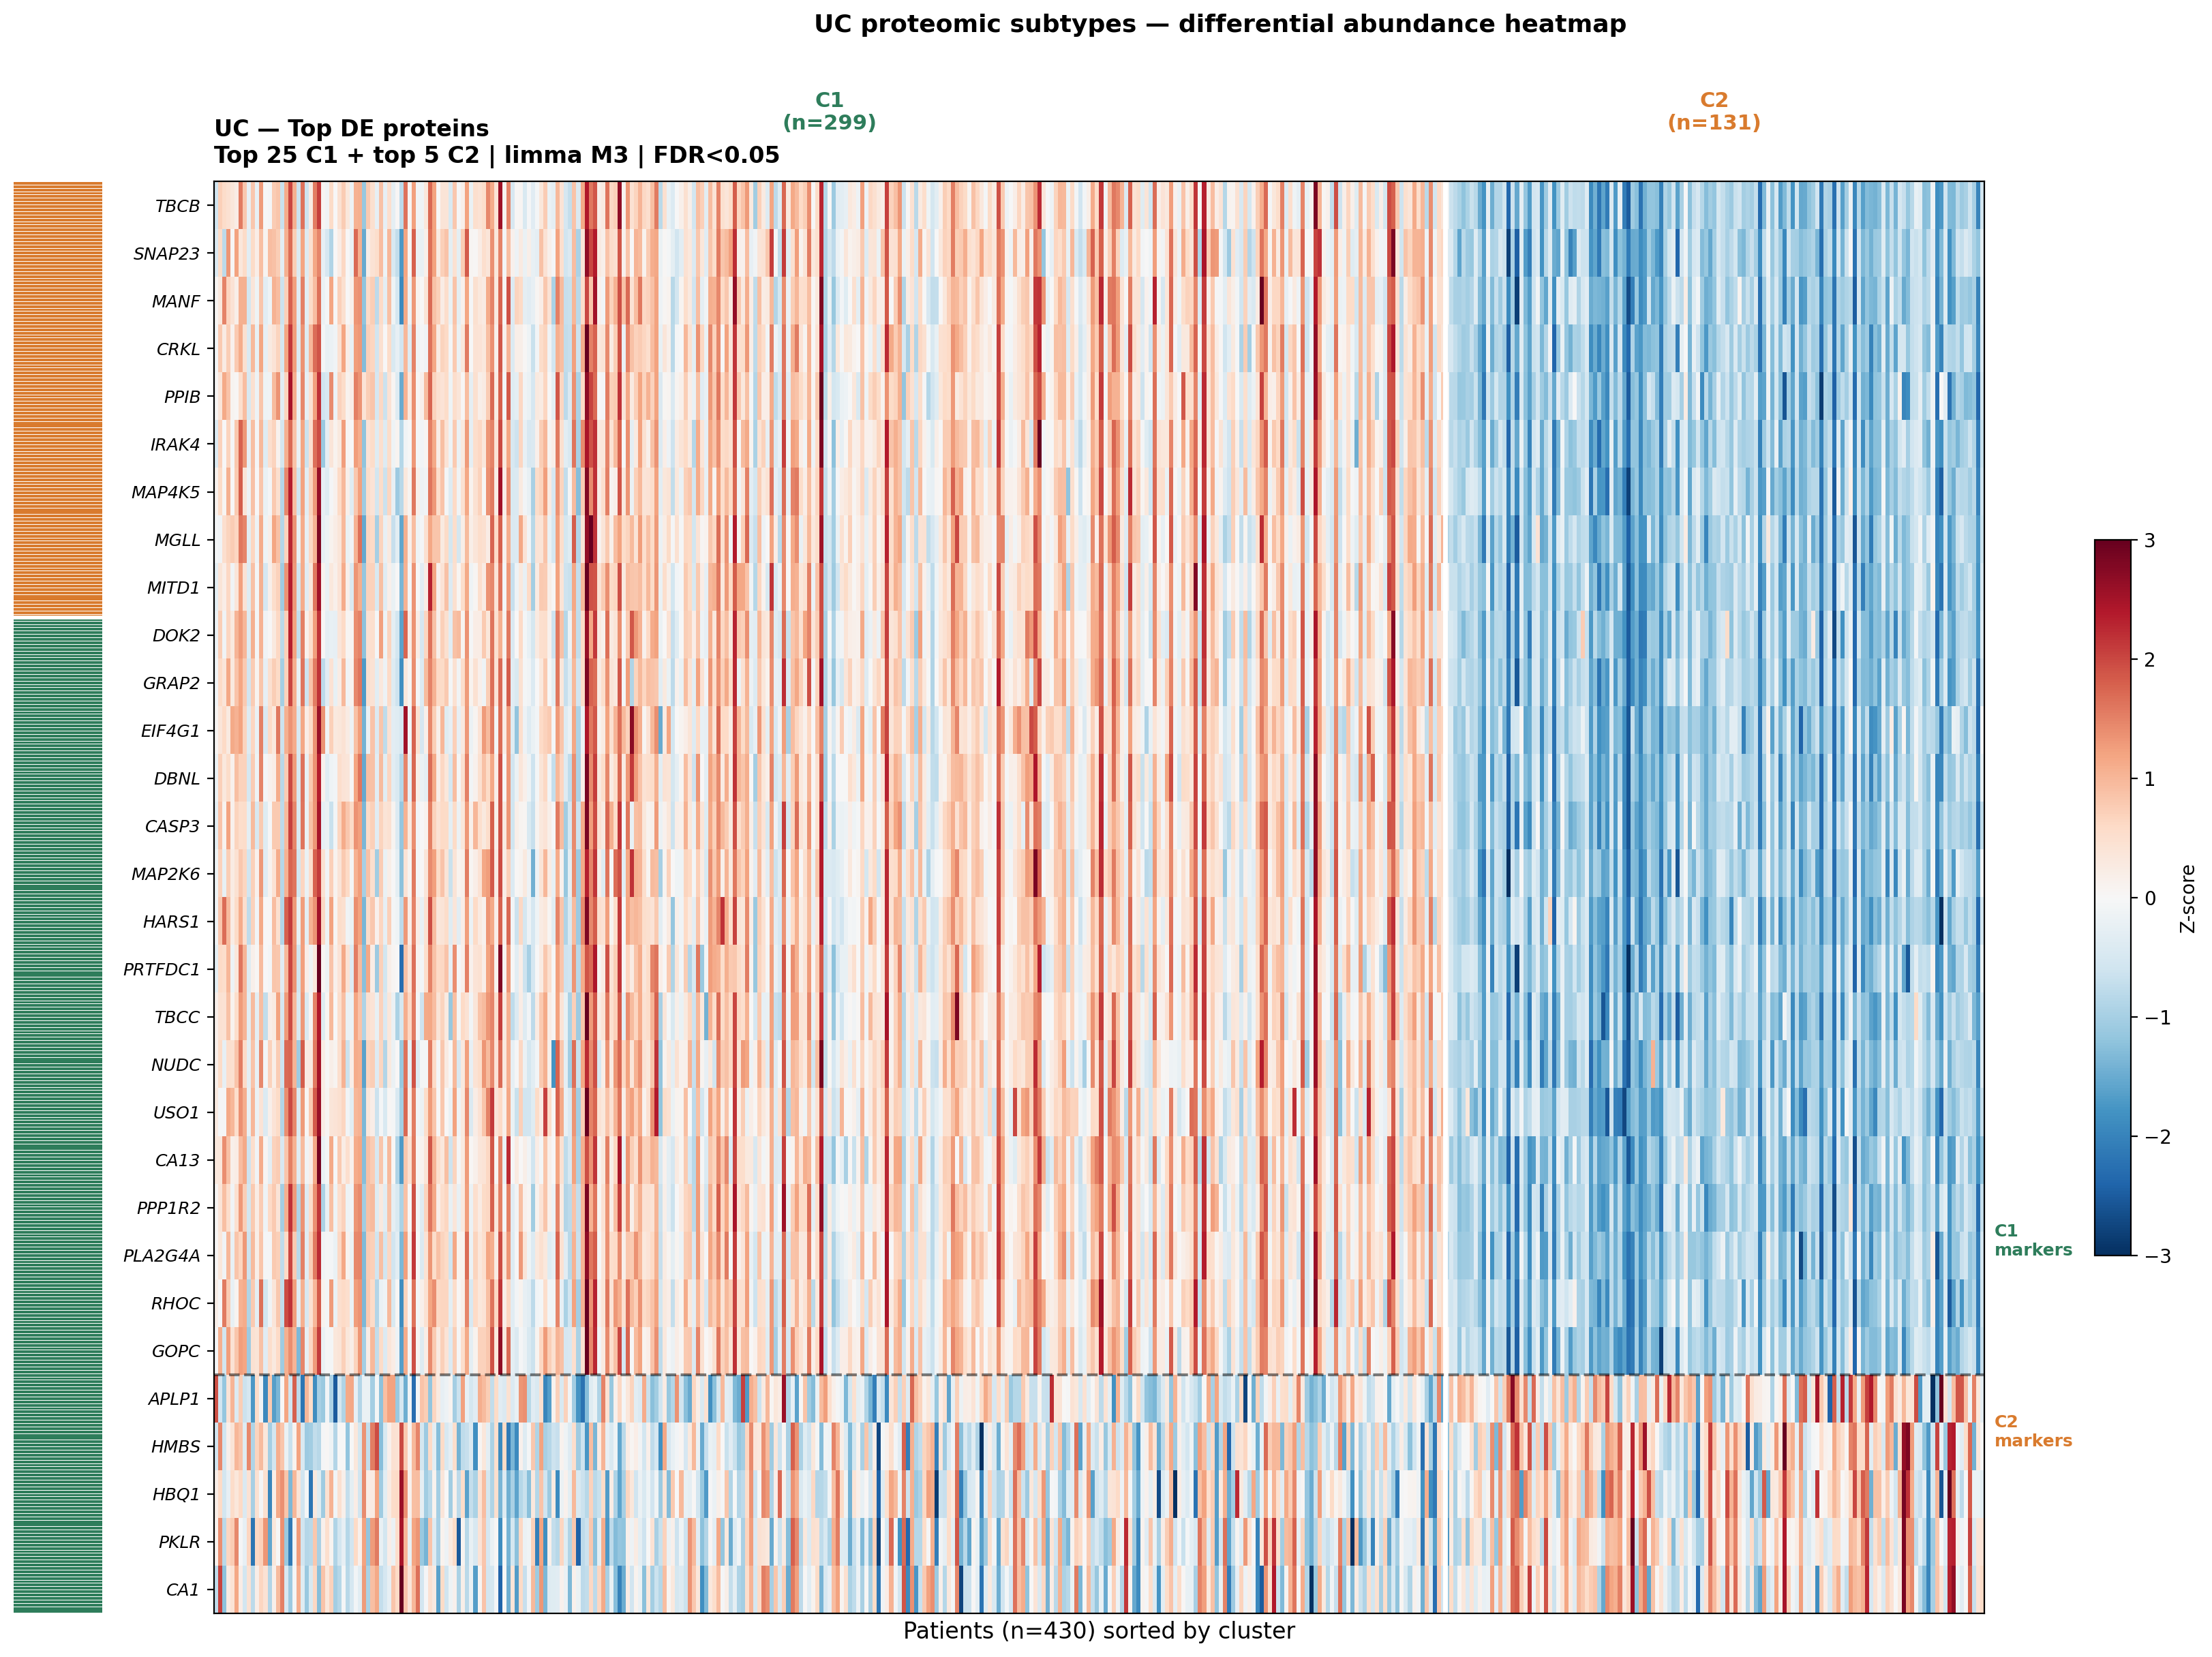


hallmark_cd.png (221 KB):


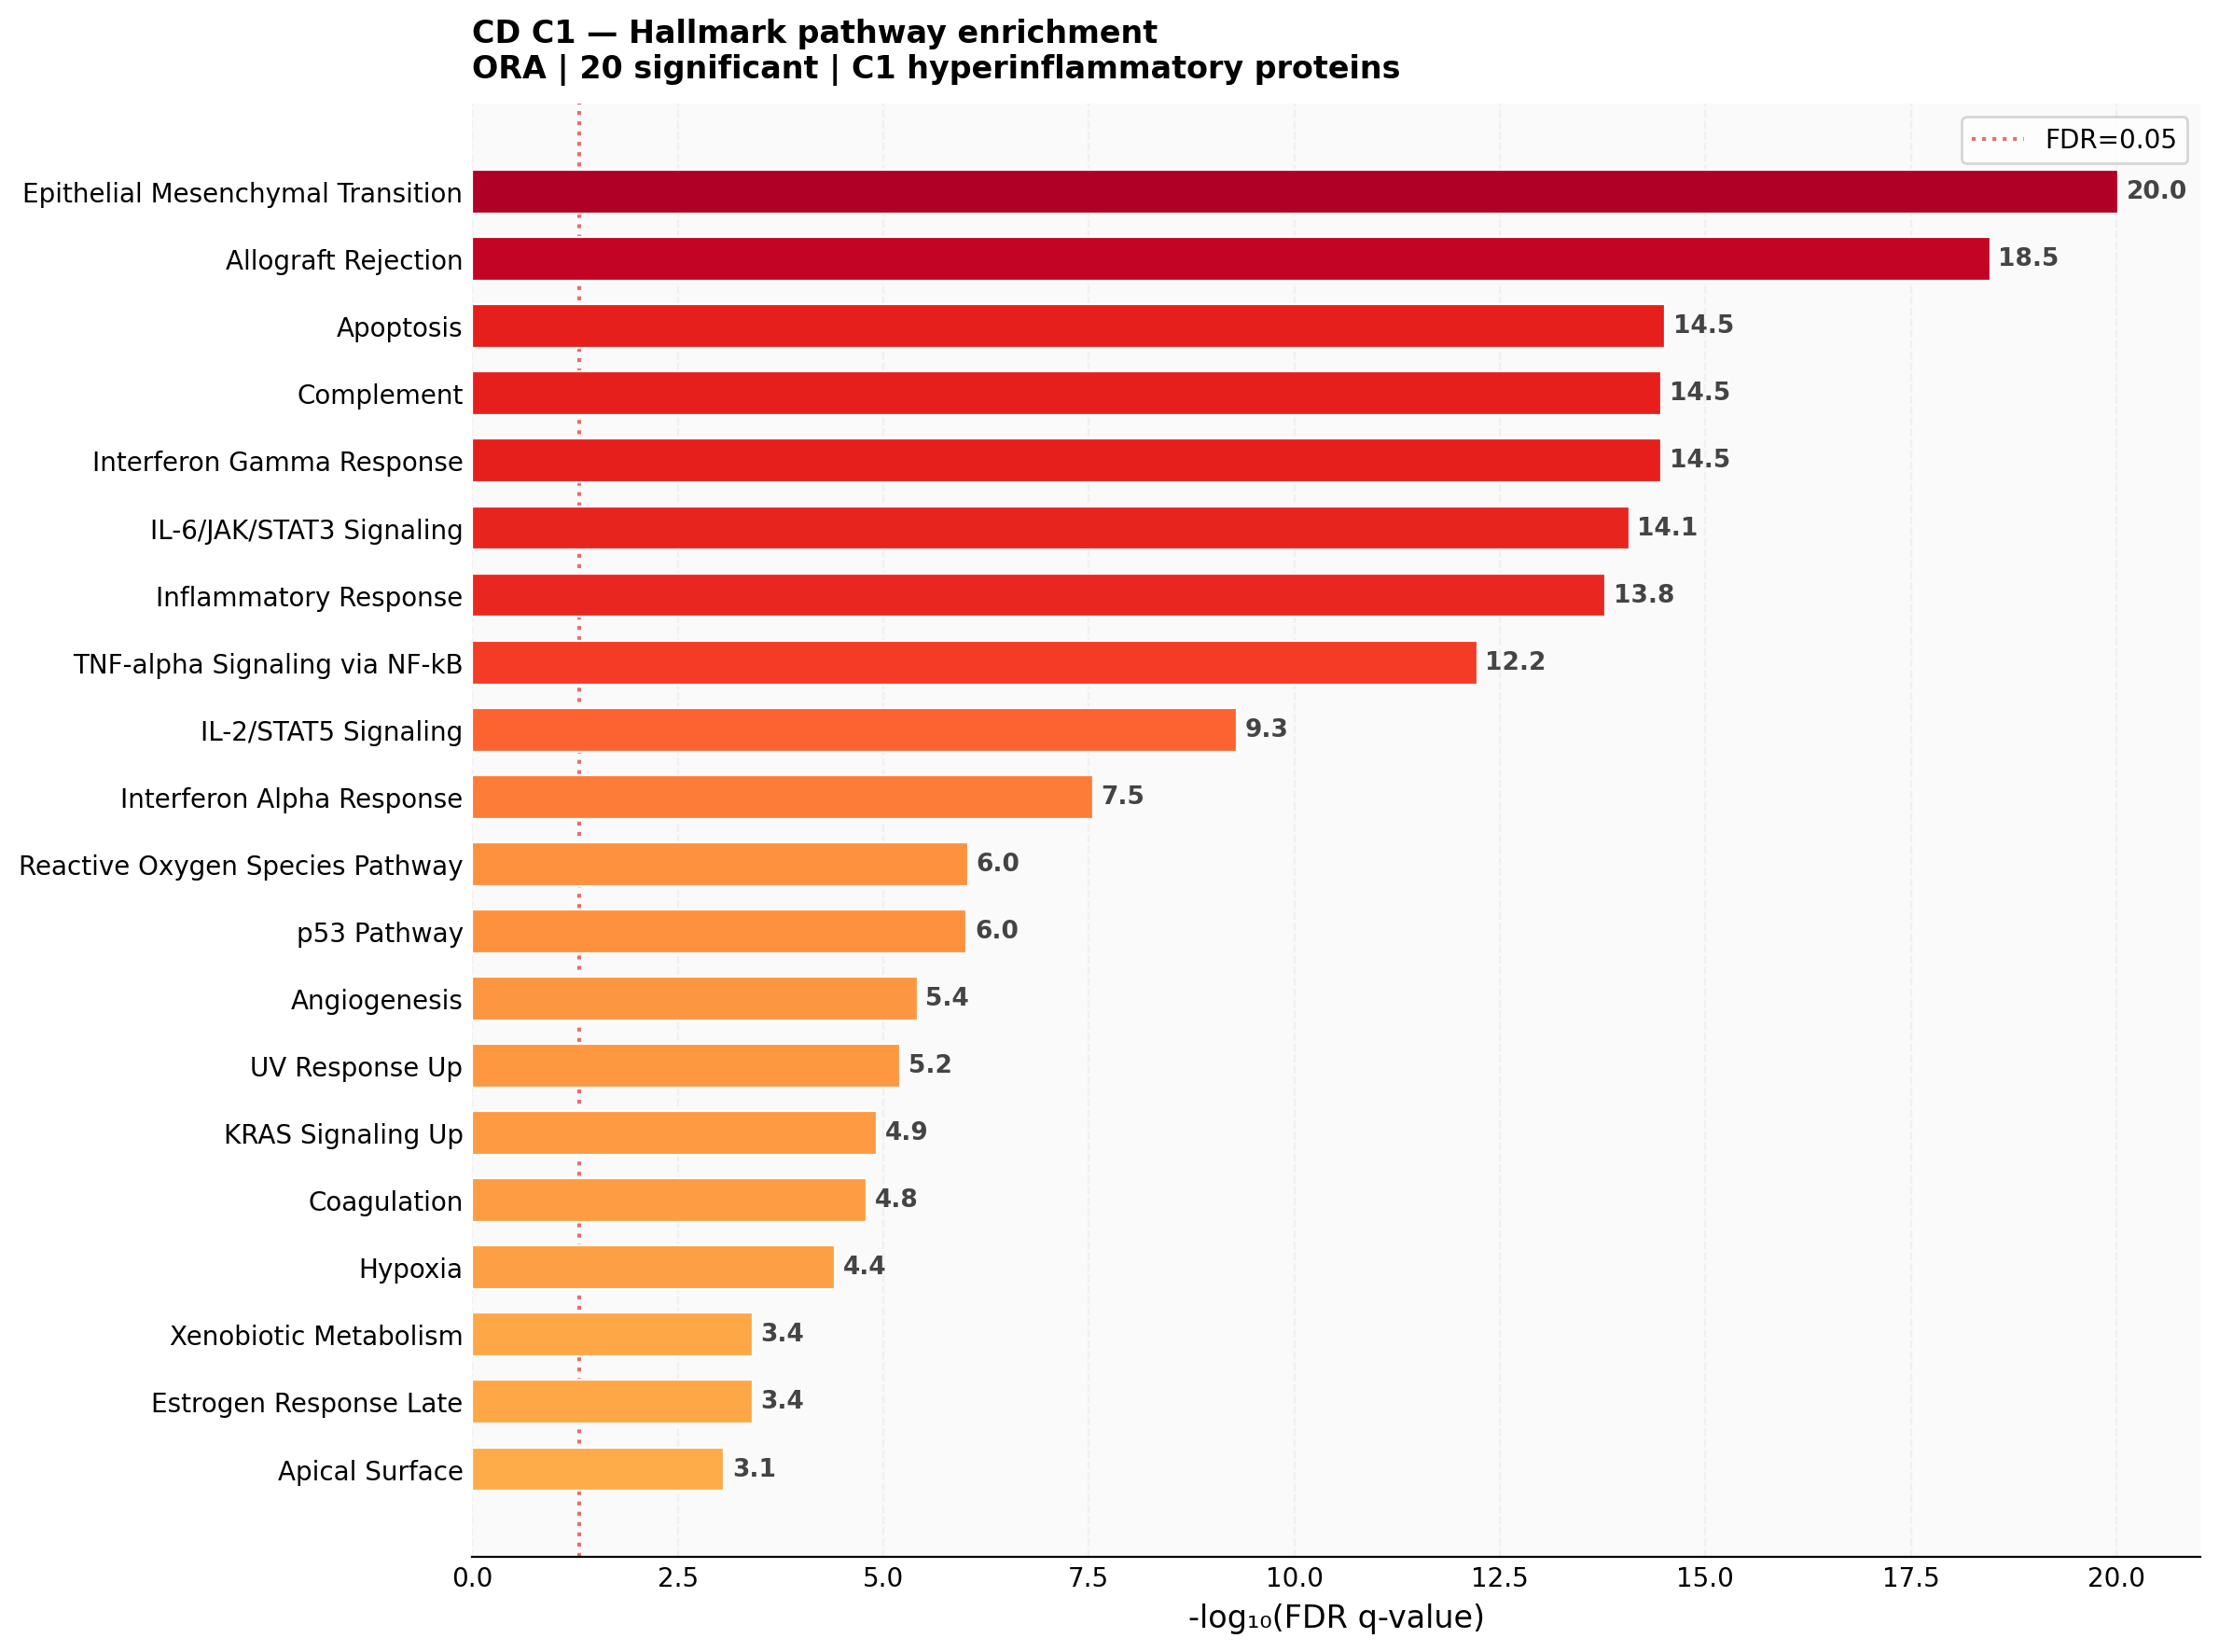


hallmark_uc.png (212 KB):


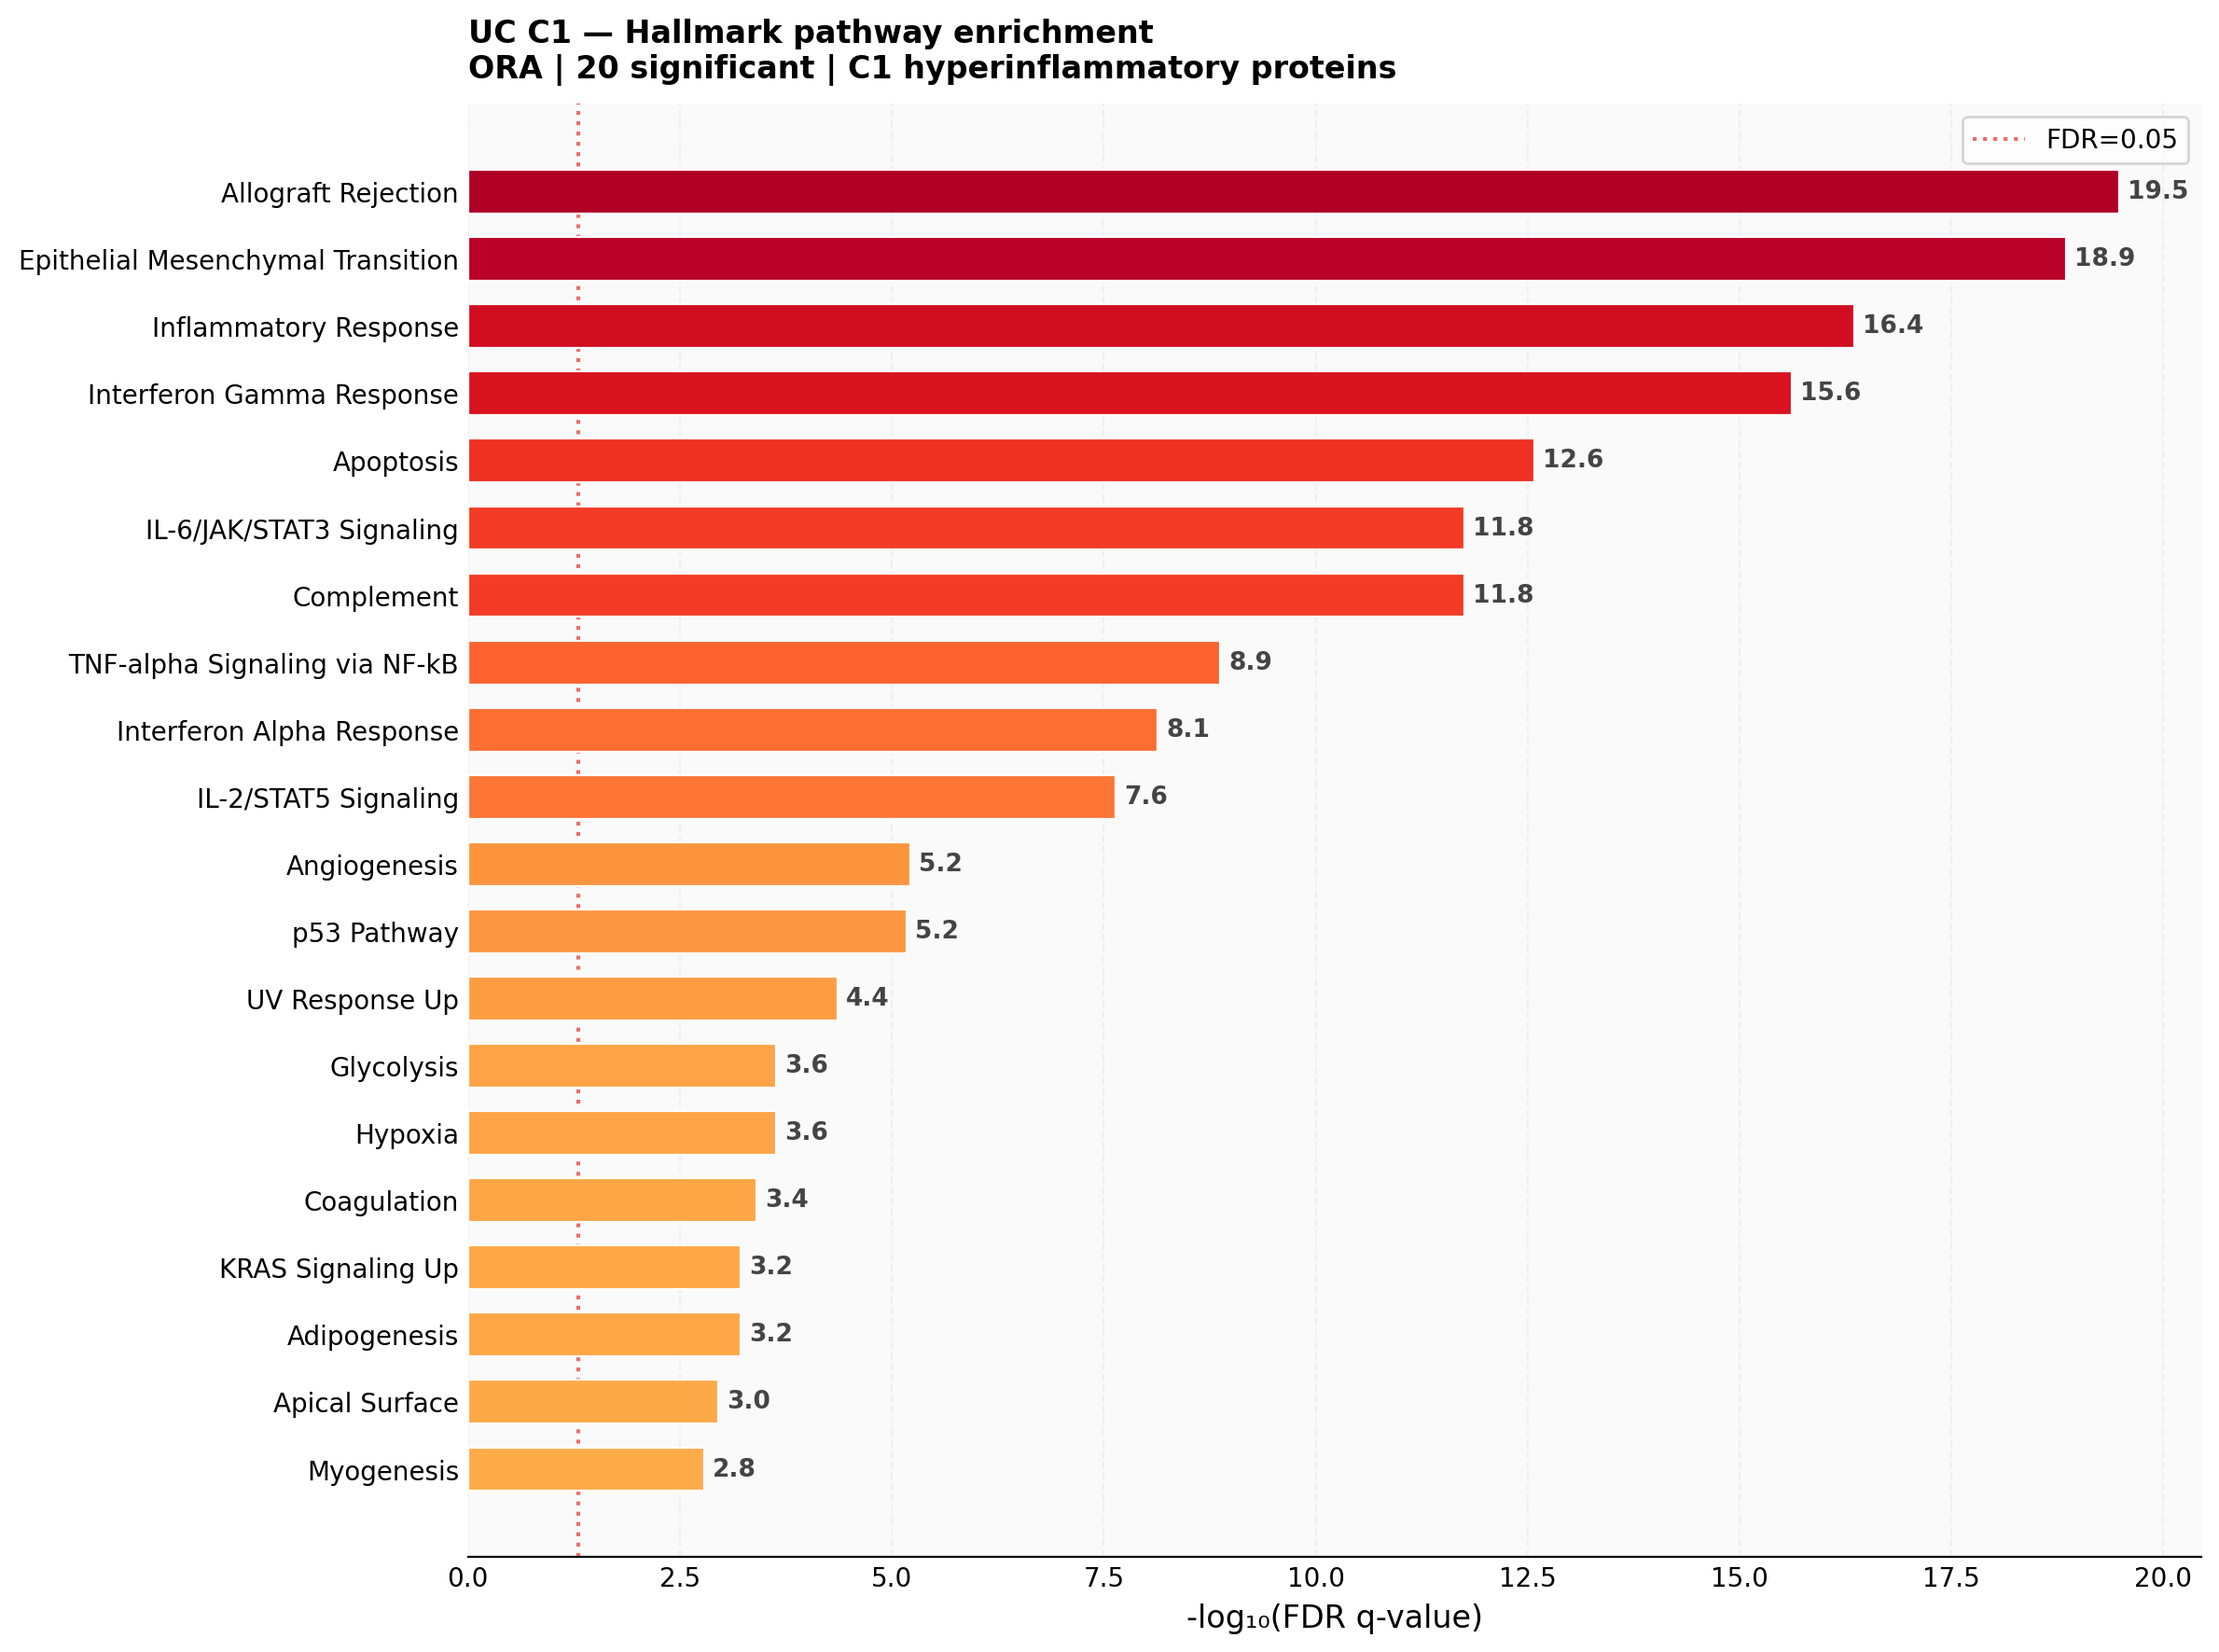


rf_triangulation_cd.png (300 KB):


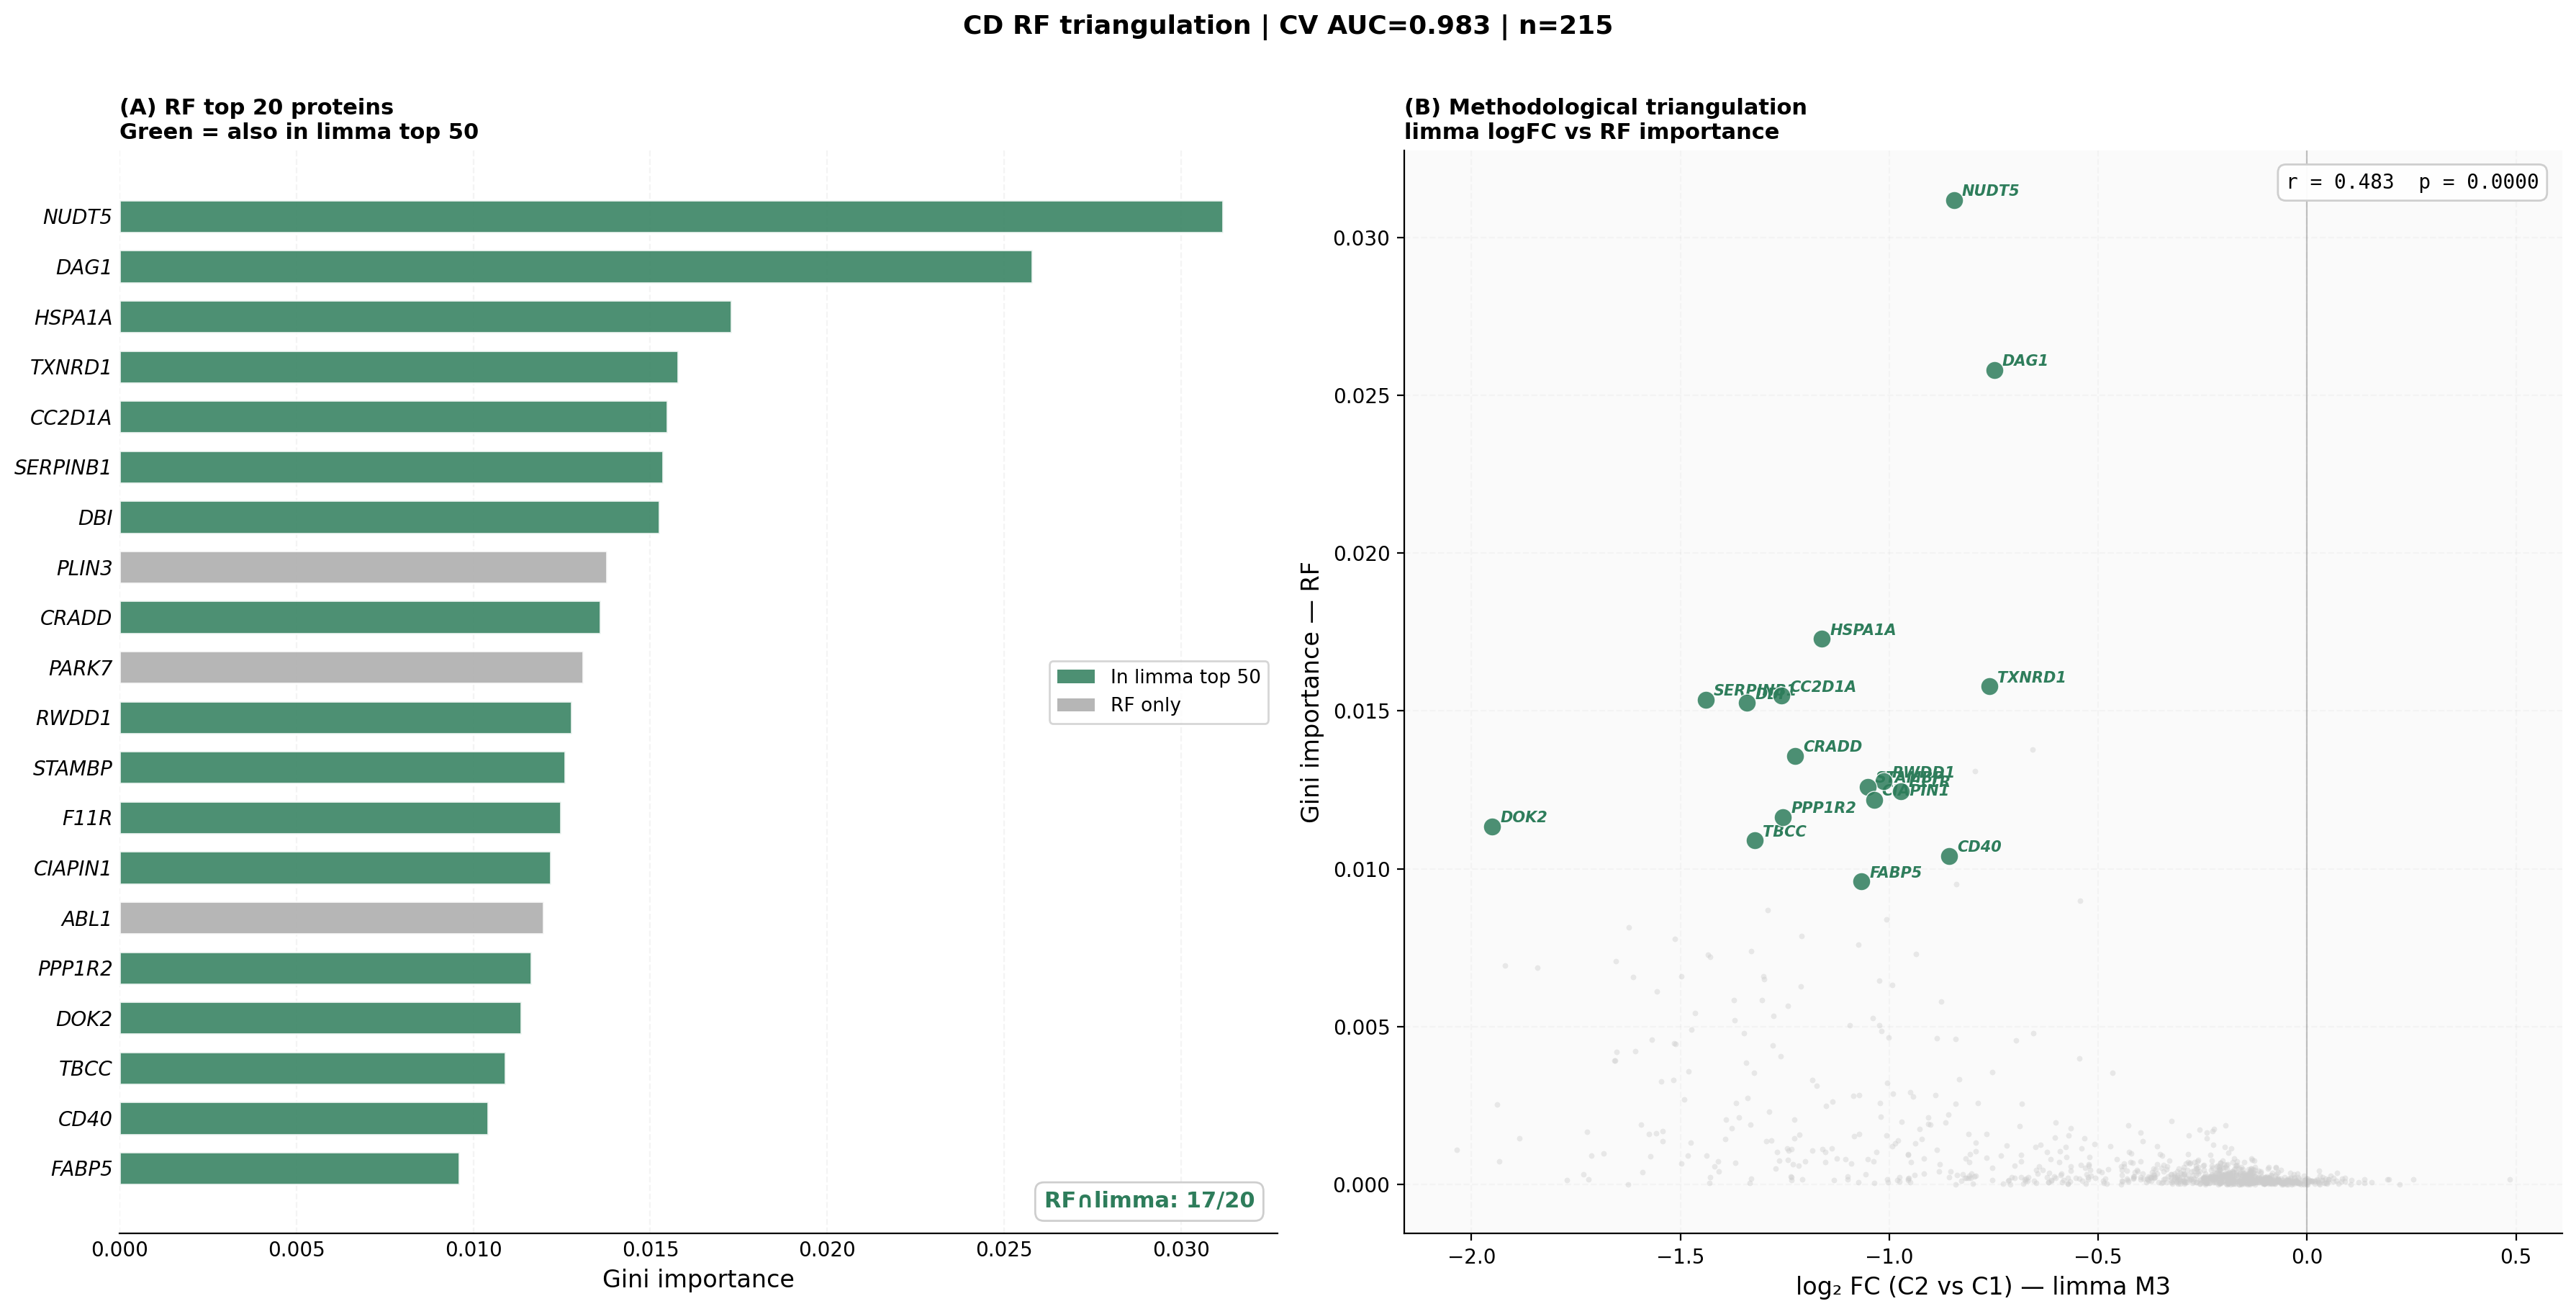


rf_triangulation_uc.png (301 KB):


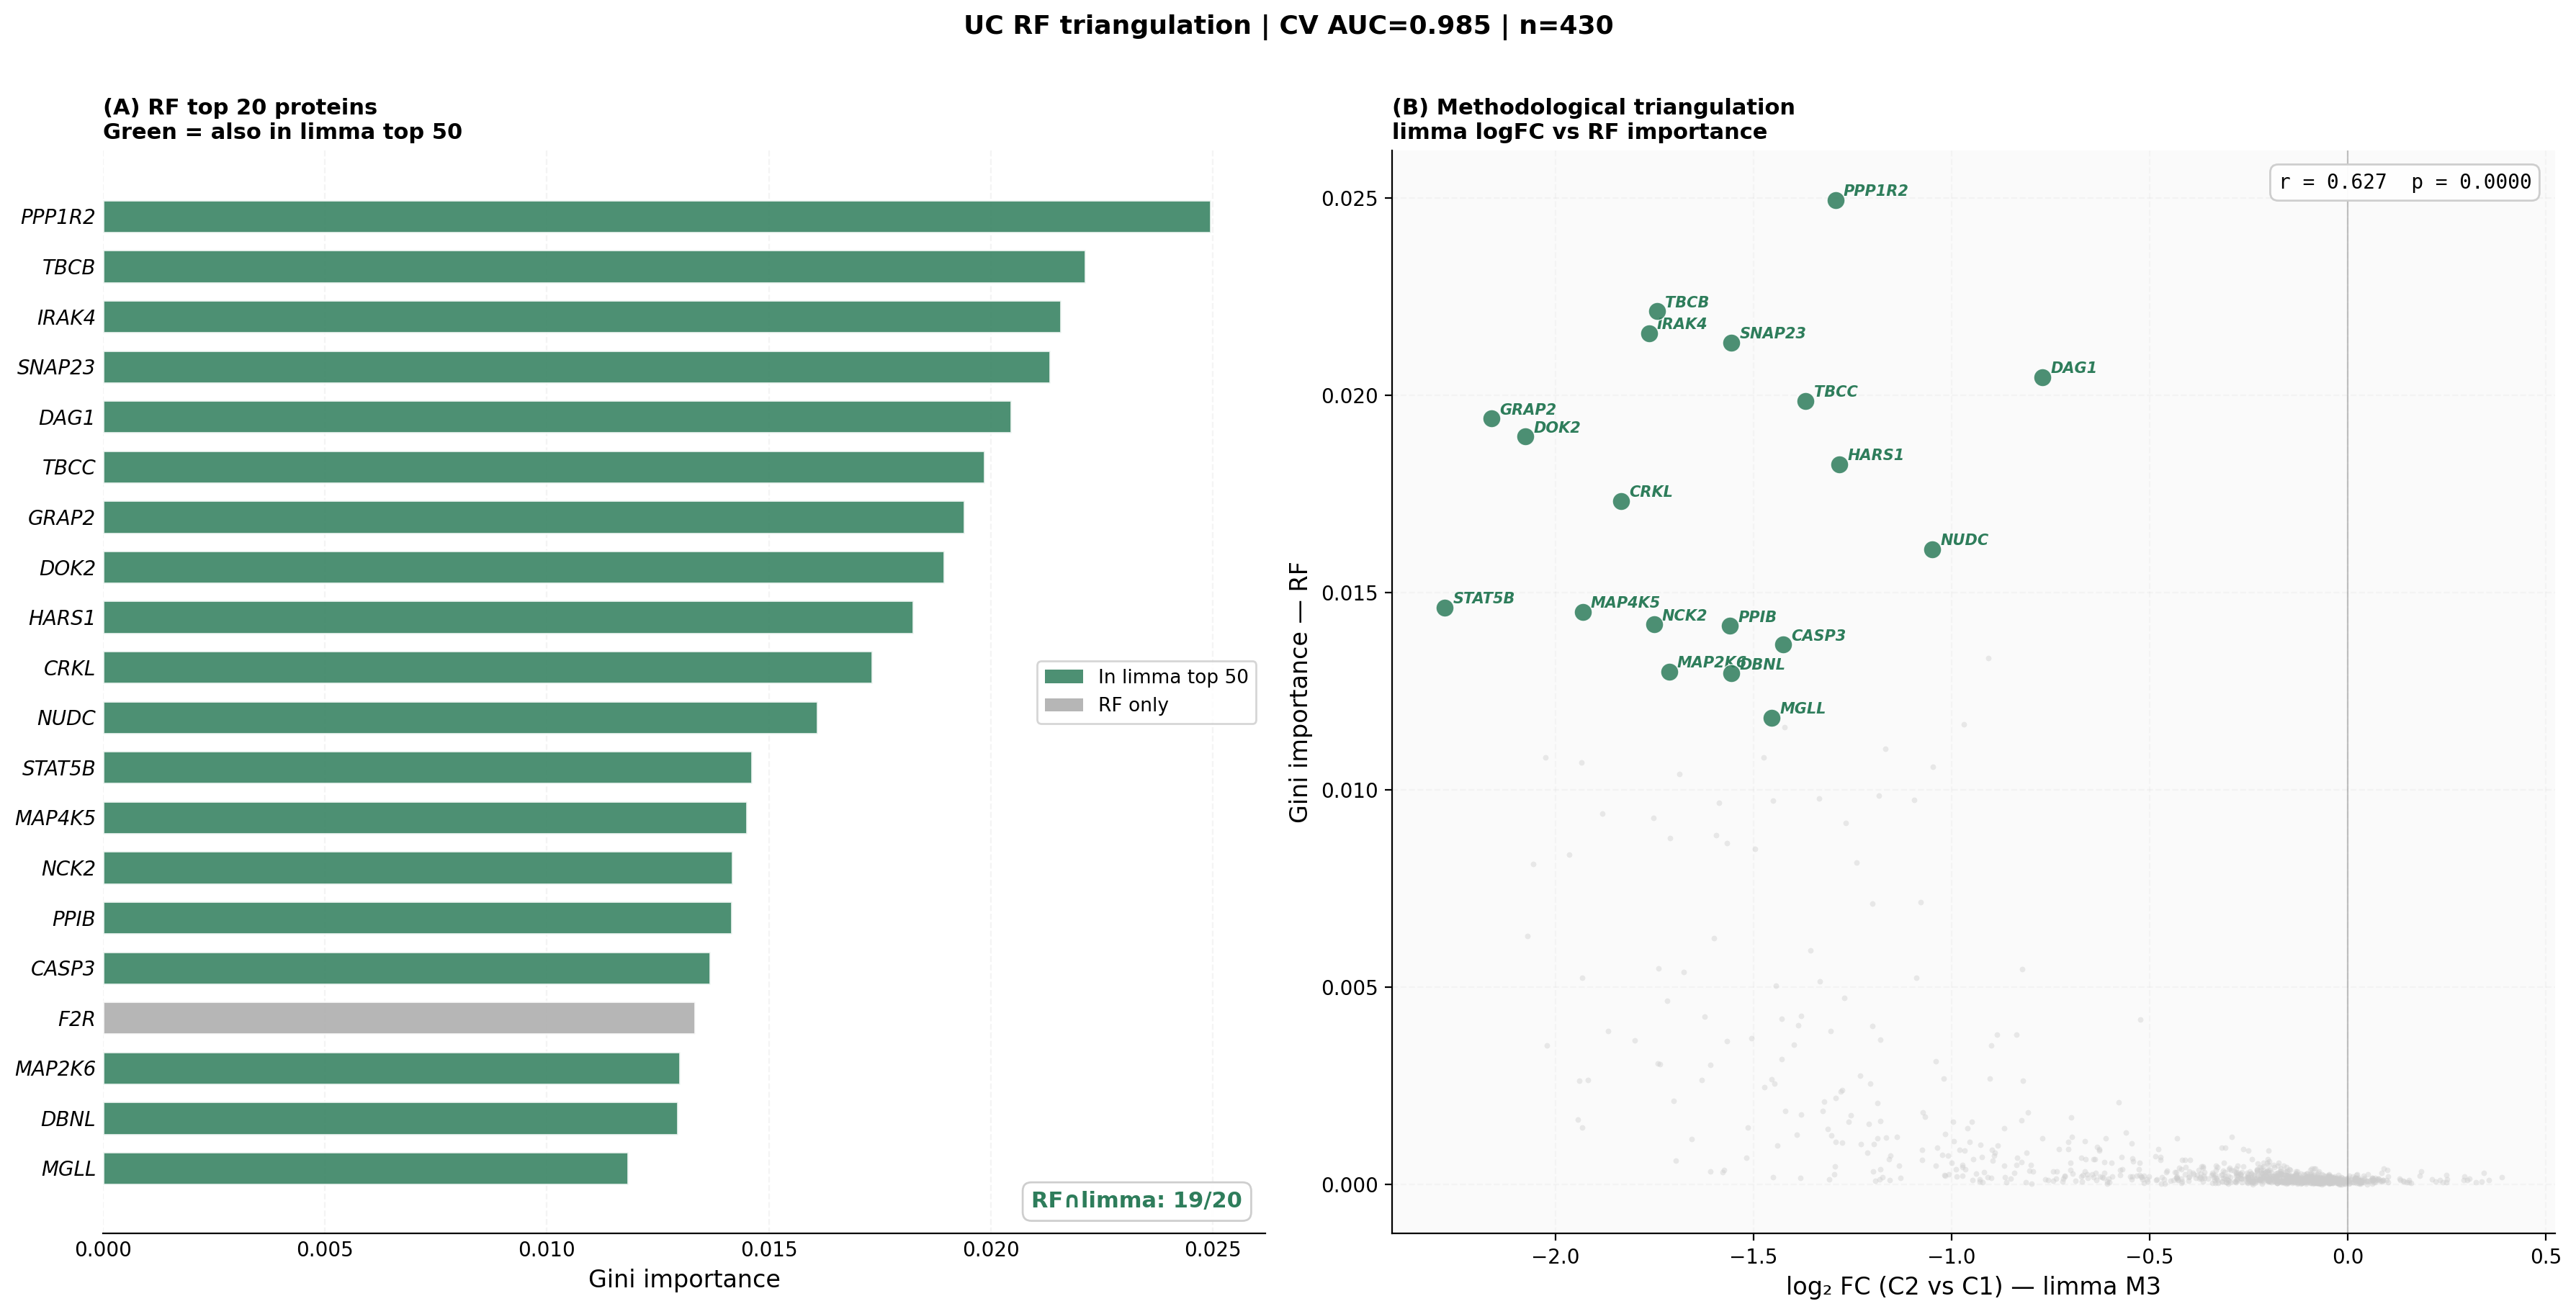


ALL FIGURES COMPLETE
Next: IBDome validation


In [10]:
# ── Figure 4: RF triangulation ────────────────────
def make_rf_figure(cohort):
    rf_imp = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_rf_importance.csv')
    limma  = pd.read_csv(
        f'{TABLES_DIR}/'
        f'{cohort}_limma_M3.csv')

    limma_top50 = limma.nsmallest(
        50,'adj.P.Val')['protein'].tolist()
    top20_p = rf_imp.head(20)['protein'].tolist()
    top20_i = rf_imp.head(20)['gini_imp'].tolist()

    overlap = set(top20_p) & set(limma_top50)

    fig, axes = plt.subplots(
        1, 2, figsize=(18,9))
    fig.patch.set_facecolor('white')

    # Panel A: RF importance bars
    ax = axes[0]
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.2,
            linestyle='--', color='#ccc',
            zorder=0)
    ax.tick_params(length=0)

    bar_cols = [
        PALETTE[0] if p in overlap
        else '#AAAAAA'
        for p in top20_p]

    ax.barh(
        range(len(top20_p)),
        list(reversed(top20_i)),
        color=list(reversed(bar_cols)),
        alpha=0.85, height=0.65,
        edgecolor='white', zorder=3)
    ax.set_yticks(range(len(top20_p)))
    ax.set_yticklabels(
        list(reversed(top20_p)),
        fontsize=10, style='italic')
    ax.set_xlabel('Gini importance',
                   fontsize=12)
    ax.set_title(
        '(A) RF top 20 proteins\n'
        'Green = also in limma top 50',
        fontsize=11, fontweight='700',
        loc='left')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor=PALETTE[0],
               alpha=0.85,
               label='In limma top 50'),
        Patch(facecolor='#AAAAAA',
               alpha=0.85,
               label='RF only')],
        fontsize=9.5)
    ax.text(
        0.98, 0.02,
        f'RF∩limma: {len(overlap)}/20',
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=11, fontweight='700',
        color=PALETTE[0],
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='#ccc',
            alpha=0.95))

    # Panel B: Scatter logFC vs importance
    ax = axes[1]
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.15, linestyle='--',
            color='#ccc', zorder=0)

    limma_idx = limma.set_index('protein')
    n_prots   = min(len(prots),
                     rf_imp.shape[0])
    rf_sub    = rf_imp[
        rf_imp['protein'].isin(
            prots[:n_prots])]

    logfc_vals = []
    imp_vals   = []
    in_overlap = []
    prot_names = []

    for _, row in rf_sub.iterrows():
        p = row['protein']
        if p in limma_idx.index:
            logfc_vals.append(
                limma_idx.loc[p,'logFC'])
            imp_vals.append(row['gini_imp'])
            in_overlap.append(p in overlap)
            prot_names.append(p)

    logfc_arr = np.array(logfc_vals)
    imp_arr   = np.array(imp_vals)
    ov_arr    = np.array(in_overlap)

    ax.scatter(
        logfc_arr[~ov_arr],
        imp_arr[~ov_arr],
        c='#CCCCCC', s=8, alpha=0.4,
        linewidths=0, zorder=1)
    ax.scatter(
        logfc_arr[ov_arr],
        imp_arr[ov_arr],
        c=PALETTE[0], s=80,
        alpha=0.85, linewidths=0.5,
        edgecolors='white', zorder=4)

    for p, lfc, imp in zip(
            np.array(prot_names)[ov_arr],
            logfc_arr[ov_arr],
            imp_arr[ov_arr]):
        ax.annotate(
            p, (lfc, imp),
            fontsize=7.5, style='italic',
            fontweight='600',
            color=PALETTE[0],
            xytext=(4,2),
            textcoords='offset points')

    ax.axvline(0, color='#888',
                linewidth=0.8, alpha=0.5)
    ax.set_xlabel('log₂ FC (C2 vs C1) '
                   '— limma M3',
                   fontsize=12)
    ax.set_ylabel('Gini importance — RF',
                   fontsize=12)
    ax.set_title(
        '(B) Methodological triangulation\n'
        'limma logFC vs RF importance',
        fontsize=11, fontweight='700',
        loc='left')

    from scipy import stats as scipy_stats
    if len(logfc_arr) > 3:
        r,p_val = scipy_stats.pearsonr(
            np.abs(logfc_arr), imp_arr)
        ax.text(0.98, 0.98,
                 f'r = {r:.3f}  p = {p_val:.4f}',
                 transform=ax.transAxes,
                 ha='right', va='top',
                 fontsize=10,
                 fontfamily='monospace',
                 bbox=dict(
                     boxstyle='round,pad=0.4',
                     facecolor='white',
                     edgecolor='#ccc',
                     alpha=0.95))

    plt.suptitle(
        f'{cohort.upper()} RF triangulation | '
        f'CV AUC={"0.983" if cohort=="cd" else "0.985"} | '
        f'n={"215" if cohort=="cd" else "430"}',
        fontsize=13, fontweight='900',
        y=1.01)
    plt.tight_layout()
    fname = (f'{FIGURES_DIR}/'
              f'rf_triangulation_{cohort}.png')
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: '
          f'rf_triangulation_{cohort}.png')

make_rf_figure('cd')
make_rf_figure('uc')

# Display all
print('\nDisplaying all figures...')
for fname in [
    'volcano_cd.png','volcano_uc.png',
    'heatmap_cd.png','heatmap_uc.png',
    'hallmark_cd.png','hallmark_uc.png',
    'rf_triangulation_cd.png',
    'rf_triangulation_uc.png']:
    path = f'{FIGURES_DIR}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path)//1024
        print(f'\n{fname} ({size} KB):')
        display(Image(filename=path,
                      width=900))

print('\nALL FIGURES COMPLETE')
print('Next: IBDome validation')